In [1]:
import argparse
import os
import re

import torch.nn.functional as F

os.environ["TORCHINDUCTOR_DISABLE"] = "1"
os.environ["TORCH_COMPILE"] = "0"
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["DISABLE_TORCH_COMPILE"] = "1"
os.environ["TRANSFORMERS_NO_COMPILE"] = "1"
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from safetensors.torch import load_file as load_safetensors
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (adjusted_rand_score, balanced_accuracy_score,
                             calinski_harabasz_score, classification_report,
                             davies_bouldin_score, pairwise_distances,
                             silhouette_score)
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import umap
import glob
from scipy.stats import spearmanr


/home/fe/purelku/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/fe/purelku/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
models = [ "google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]


output_dir = "/data/erblina/Master_thesis"

datasets_list = ["walledai/AdvBench","walledai/DTStereotype", "walledai/CatHarmfulQA","walledai/DTToxicity","truthfulqa/truthful_qa"]


model_steering_1 = {'Qwen/Qwen2.5-3B': {'layers': [ 'model.layers.19', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 1.6, 1.6, 1.6], 'alphas_down': [ -1.8, -2.0, -2.0], 'max_avg_tox': [0.87, 0.87, 0.795, 0.76], 'min_avg_tox': [0.21, 0.21, 0.22, 0.19]},
    'Qwen/Qwen2.5-3B-Instruct': {'layers': [ 'model.layers.21', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 2.0, 2.0, 2.0], 'alphas_down': [ -0.6, -0.6, -0.6], 'max_avg_tox': [0.79, 0.79, 0.785, 0.78], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B-Instruct': {'layers': [ 'model.layers.9', 'model.layers.7', 'model.layers.8'], 'alphas_up': [ 2.0, 1.8, 1.6], 'alphas_down': [ -0.8, -1.0, -0.8], 'max_avg_tox': [0.75, 0.75, 0.735, 0.715], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B': {'layers': ['model.layers.5', 'model.layers.7', 'model.layers.4'], 'alphas_up': [-0.15, -0.07, 0.05], 'alphas_down': [-2.0, -1.5, -2.0], 'max_avg_tox': [0.4, 0.39, 0.39], 'min_avg_tox': [0.09, 0.085, 0.09]},
    'google/gemma-2-2b-it': {'layers': [ 'model.layers.10', 'model.layers.11', 'model.layers.12'], 'alphas_up': [ 1.5, 1.1, 1.0], 'alphas_down': [-0.3, -0.25, -0.2], 'max_avg_tox': [0.63, 0.63, 0.615, 0.595], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'meta-llama/Llama-3.2-3B-Instruct': {'layers': [ 'model.layers.12', 'model.layers.13', 'model.layers.14'], 'alphas_up': [ 2.0, 1.6, 2.0], 'alphas_down': [ -0.8, -0.5, -0.5], 'max_avg_tox': [0.82, 0.82, 0.81, 0.79], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'google/gemma-2-2b': {'layers': [ 'model.layers.6', 'model.layers.7', 'model.layers.13'], 'alphas_up': [ 1.2, 1.3, 1.4], 'alphas_down': [ -2.0, -1.8, -1.8], 'max_avg_tox': [0.36, 0.36, 0.35, 0.36], 'min_avg_tox': [0.135, 0.02, 0.035, 0.065]},
    'meta-llama/Llama-3.2-3B': {'layers': [ 'model.layers.12', 'model.layers.10', 'model.layers.11'], 'alphas_up': [ 0.7, 1.0, 1.0], 'alphas_down': [ -2.0, -1.4, -1.6], 'max_avg_tox': [0.605, 0.57, 0.575, 0.6], 'min_avg_tox': [0.385, 0.3, 0.33, 0.36]},
        }

In [3]:
def load_harmbench(model, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    ###### HARMBENCH DATASET ######
    labels = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    hidden_states = load_safetensors(
        os.path.join(f"{output_dir}/{safe_model_name}", f"hidden_states_pure.safetensors"))
    
    side = 'toxic'
    # # Define path pattern
    # pattern = f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_*.npy"

    # # Find all matching files
    # files = sorted(glob.glob(pattern))

    # # Load them into a dictionary keyed by alpha
    # data = {}
    # for file in files:
    #     # Extract the alpha value from filename
    #     alpha_str = os.path.splitext(os.path.basename(file))[0].split('_alpha_')[-1]
    #     alpha = float(alpha_str)
    #     data[alpha] = np.load(file, allow_pickle=True).item()

    return hidden_states, labels #, data

def load_datasets(model, dataset, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
    hidden_states_data = load_safetensors(os.path.join(output_dir, safe_model_name, f"{safe_dataset}_hidden_states_pure.safetensors"))
    labels_data = np.load(f"{output_dir}/{safe_model_name}/labels_{safe_dataset}.npy")

    return hidden_states_data, labels_data

def load_steering_dataset(model, dataset, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after_dataset = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_dataset_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after_dataset,
            alpha_d : labels_after_dataset_d
        }

    return data

def load_steering_harmbench(model, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after,
            alpha_d : labels_after_d
        }

    return data


In [4]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap  # <-- add this import


def plot_dim_reduction_comparison(X, y):
    n_neighbors = 5
    random_state = 0

    X_c = np.concatenate(X, axis=0)
    y_c = np.concatenate(y, axis=0)

    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_c, y_c, test_size=0.5, stratify=y_c, random_state=random_state
    )

    dim = len(X_c[0])
    n_classes = len(np.unique(y_c))

    # Reduce dimension to 2 with PCA
    pca = make_pipeline(StandardScaler(), PCA(n_components=2, random_state=random_state))

    # Reduce dimension to 2 with LinearDiscriminantAnalysis
    lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(n_components=2))

    # Reduce dimension to 2 with NeighborhoodComponentAnalysis
    nca = make_pipeline(
        StandardScaler(),
        NeighborhoodComponentsAnalysis(n_components=2, random_state=random_state),
    )

    # Use a nearest neighbor classifier to evaluate the methods
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)

    # Make a list of the methods to be compared
    dim_reduction_methods = [("PCA", pca), ("NCA", nca)] #("LDA", lda)] #, 
    c = plt.cm.get_cmap("Set1", len(X))
    # plt.figure()
    for i, (name, model) in enumerate(dim_reduction_methods):
        plt.figure()
        # plt.subplot(1, 3, i + 1, aspect=1)

        # Fit the method's model
        model.fit(X_train, y_train)

        # Fit a nearest neighbor classifier on the embedded training set
        knn.fit(model.transform(X_train), y_train)

        # Compute the nearest neighbor accuracy on the embedded test set
        acc_knn = knn.score(model.transform(X_test), y_test)

        for i, (X_, y_) in enumerate(zip(X, y)):
            # Embed the data set in 2 dimensions using the fitted model
            X_embedded = model.transform(X_)

            # Plot the projected points and show the evaluation score
            plt.scatter(X_embedded[:, 0][y_ == 0], X_embedded[:, 1][y_ == 0], c=c(i), s=30, alpha=0.3, marker='o', zorder=1)

            plt.scatter(X_embedded[:, 0][y_ == 1], X_embedded[:, 1][y_ == 1], c=c(i), s=80, alpha=0.7, marker='x', zorder=1)

        plt.title(
            "{}, KNN (k={})\nTest accuracy = {:.2f}".format(name, n_neighbors, acc_knn)
        )
    plt.show()
    plt.close()


In [ ]:
import numpy as np
from scipy.stats import ks_2samp, mannwhitneyu, epps_singleton_2samp
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def marginal_tests_1d(x, y):
    """Two-sample tests between y=0 and y=1 for a 1D projection x."""
    x0, x1 = x[y==0], x[y==1]
    ks = ks_2samp(x0, x1)
    mw = mannwhitneyu(x0, x1, alternative="two-sided")
    es = epps_singleton_2samp(x0, x1)
    return {
        "KS": (ks.statistic, ks.pvalue),
        "MW": (mw.statistic, mw.pvalue),
        "ES": (es.statistic, es.pvalue),
    }

def _mmd2_rbf_unbiased(X, Y, gamma=None):
    """Unbiased MMD^2 with RBF kernel; returns (mmd2, gamma_used)."""
    if gamma is None:
        # median heuristic for bandwidth
        Z = np.vstack([X, Y])
        d2 = ((Z[:,None,:]-Z[None,:,:])**2).sum(-1)
        med2 = np.median(d2[d2>0])
        gamma = 1.0 / (2.0 * (med2 + 1e-12))
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n = len(X); m = len(Y)
    Kxx_off = (Kxx.sum() - np.trace(Kxx)) / (n*(n-1))
    Kyy_off = (Kyy.sum() - np.trace(Kyy)) / (m*(m-1))
    Kxy_all = Kxy.mean()
    mmd2 = Kxx_off + Kyy_off - 2*Kxy_all
    return mmd2, gamma

# def mmd_test_2d(X0, X1, B=500, gamma=None, rng=None):
#     """Permutation test for equality of 2D distributions via MMD.
#        Returns dict with MMD^2 and p-value.
#     """
#     rng = np.random.default_rng(None if rng is None else rng)
#     obs, gamma = _mmd2_rbf_unbiased(X0, X1, gamma=gamma)
#     Z = np.vstack([X0, X1])
#     n0 = len(X0)
#     boots = np.empty(B)
#     for b in range(B):
#         idx = rng.permutation(len(Z))
#         X0b, X1b = Z[idx[:n0]], Z[idx[n0:]]
#         boots[b], _ = _mmd2_rbf_unbiased(X0b, X1b, gamma=gamma)
#     pval = (np.sum(boots >= obs) + 1) / (B + 1)
#     return {"mmd2": float(obs), "p": float(pval), "gamma": float(gamma)}

def mmd_test_2d(X0, X1, B=500, gamma=None, rng=None):
    rng = np.random.default_rng(None if rng is None else rng)
    X0 = np.asarray(X0); X1 = np.asarray(X1)
    n0, n1 = len(X0), len(X1)

    # Select/compute gamma on pooled data
    Z = np.vstack([X0, X1])
    if gamma is None:
        d2 = ((Z[:, None, :] - Z[None, :, :])**2).sum(-1)
        med2 = np.median(d2[d2 > 0])
        gamma = 1.0 / (2.0 * (med2 + 1e-12))

    # Precompute Gram on pooled samples once
    K = rbf_kernel(Z, Z, gamma=gamma)

    def mmd2_from_indices(idx_a, idx_b):
        n, m = len(idx_a), len(idx_b)
        Ka = K[np.ix_(idx_a, idx_a)]
        Kb = K[np.ix_(idx_b, idx_b)]
        Kab = K[np.ix_(idx_a, idx_b)]
        Ka_off = (Ka.sum() - np.trace(Ka)) / (n*(n-1))
        Kb_off = (Kb.sum() - np.trace(Kb)) / (m*(m-1))
        return Ka_off + Kb_off - 2.0 * Kab.mean()

    obs = mmd2_from_indices(np.arange(n0), np.arange(n0, n0+n1))

    boots = np.empty(B, dtype=float)
    for b in range(B):
        perm = rng.permutation(n0 + n1)
        boots[b] = mmd2_from_indices(perm[:n0], perm[n0:])

    pval = (np.sum(boots >= obs) + 1) / (B + 1)
    return {"mmd2": float(obs), "p": float(pval), "gamma": float(gamma)}



models = [#( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
        #   ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), 
          ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]


def get_second_dir(X,y,  w, method='mean'):
    # normalize w
    w1 = w / (np.linalg.norm(w) + 1e-12)

    # projector onto orthogonal complement
    P_perp = np.eye(w1.size) - np.outer(w1, w1)
    if method == 'mean':

        Xp = X @ P_perp
        mu1 = Xp[y==1].mean(0)
        mu0 = Xp[y==0].mean(0)
        w2 = mu1 - mu0            # residual mean diff
        n = np.linalg.norm(w2) + 1e-12
        w2 = w2 / n
        auc = np.nan
    elif method == 'pca':
        Xc = X - X.mean(axis=0, keepdims=True)     # center data
        w1 = w / np.linalg.norm(w)

        # --- find new direction orthogonal to w with largest variance ---
        # deflate along w
        X_res = Xc - np.outer(Xc @ w1, w1)

        # SVD of the residual data
        _, _, Vt = np.linalg.svd(X_res, full_matrices=False)
        w2 = Vt[0]  
        auc = np.nan
    else:
        X_perp = X @ P_perp
        clf = LogisticRegression(max_iter=2000).fit(X_perp, y)
        w2 = clf.coef_.ravel()
        w2 = w2 / (np.linalg.norm(w2) + 1e-12)
        yhat = clf.predict(X_perp)
        auc = balanced_accuracy_score(y, yhat)
        auc = roc_auc_score(y, clf.decision_function(X_perp))

        w2_res = clf.coef_.ravel()
        w2_orig = P_perp @ w2_res
        w2 /= (np.linalg.norm(w2_orig) + 1e-12)

    return w2, auc

def plot_layerwise_results(layer_names, ks_1d_base, ks_1d_it, mmd_base, mmd_it, title=None):
    import matplotlib.pyplot as plt
    L = range(len(layer_names))

    fig, axes = plt.subplots(3, 3, figsize=(11, 10), sharex=True)
    axs = axes.ravel()

    series = {
        0: ([ks_1d_base[i]['KS'][0] for i in L], [ks_1d_it[i]['KS'][0] for i in L], "1D KS • stat"),
        1: ([ks_1d_base[i]['KS'][1] for i in L], [ks_1d_it[i]['KS'][1] for i in L], "1D KS • p"),
        2: ([ks_1d_base[i]['MW'][0] for i in L], [ks_1d_it[i]['MW'][0] for i in L], "1D MW • stat"),
        3: ([ks_1d_base[i]['MW'][1] for i in L], [ks_1d_it[i]['MW'][1] for i in L], "1D MW • p"),
        4: ([ks_1d_base[i]['ES'][0] for i in L], [ks_1d_it[i]['ES'][0] for i in L], "1D ES • stat"),
        5: ([ks_1d_base[i]['ES'][1] for i in L], [ks_1d_it[i]['ES'][1] for i in L], "1D ES • p"),
        6: ([mmd_base[i]['mmd2']      for i in L], [mmd_it[i]['mmd2']      for i in L], "2D MMD² • stat"),
        7: ([mmd_base[i]['p']         for i in L], [mmd_it[i]['p']         for i in L], "2D MMD² • p"),
        8: ([mmd_base[i]['gamma']     for i in L], [mmd_it[i]['gamma']     for i in L], "2D MMD² • γ"),
    }

    lines = []
    for k, ax in series.items():
        base, it, ttl = ax
        line1 = axs[k].plot(base, label="Base")[0]
        line2 = axs[k].plot(it,   label="Instruct")[0]
        lines = [line1, line2]  # keep last pair for legend handle tying
        axs[k].set_title(ttl)
        axs[k].grid(True, alpha=0.3)

    axs[6].set_xlabel("Layer index")
    axs[7].set_xlabel("Layer index")
    axs[8].set_xlabel("Layer index")

    if title:
        fig.suptitle(title, y=0.995)

    fig.legend(lines, ["Base", "Instruct"], loc="upper center", ncol=2)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


for pair in models:
    
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))#[5::10]
    yb = (v1b > 0).astype(int)
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    yi = (v1i > 0).astype(int)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))

    X_datab = []
    y_datab = []
    X_datai = []
    y_datai = []

    for data in datasets_list:
        X_d_b, y_d_b = load_datasets(model_base, data, output_dir)
        y_d_b = (y_d_b > 0).astype(int)
        X_datab.append(X_d_b)
        y_datab.append(y_d_b)

        X_d_i, y_d_i = load_datasets(model_it, data, output_dir)
        y_d_i = (y_d_i > 0).astype(int)
        X_datai.append(X_d_i)
        y_datai.append(y_d_i)


    t = 'toxic'
    res_base = {}
    res_it = {}

    mmd_base = []
    mmd_it = []

    ks_1d_base = []
    ks_1d_it = []
    ks_2d_base = []
    ks_2d_it = []
    for i, layer in enumerate(layer_names):
        res_base[layer] = {}
        res_it[layer] = {}
        X_allb = []
        y_allb = []
        X_alli = []
        y_alli = []

        X_allb.append(X_1b[layer].float().numpy())
        y_allb.append(yb)
        X_alli.append(X_1i[layer].float().numpy())
        y_alli.append(yi)

        for data in X_datab:
            X_allb.append(data[layer].float().numpy())
        for labels in y_datab:
            y_allb.append(labels)

        for data in X_datai:
            X_alli.append(data[layer].float().numpy())
        for labels in y_datai:
            y_alli.append(labels)
        
        X_allb = np.concatenate(X_allb, axis=0)
        y_allb = np.concatenate(y_allb, axis=0)
        X_alli = np.concatenate(X_alli, axis=0)
        y_alli = np.concatenate(y_alli, axis=0)

        for method in ['mean', 'logreg', 'pca']:
            res_base[layer][method] = []
            res_it[layer][method] = []

        for method in ['mean', 'pca', 'logreg']:
            # Get first steering vector
            w1_b = steering_vector_a[layer][t].float().numpy()
            w1_it= steering_vector_b[layer][t].float().numpy()

            # Get second steering vector
            w2_base, auc_base = get_second_dir(X_1b[layer].float().numpy(), yb, w1_b, method=method)
            w2_it, auc_it = get_second_dir(X_1i[layer].float().numpy(), yi, w1_it, method=method)

            # Compute cosine similarity between the two second directions
            # x1_b = X_1b[layer].float().numpy() @ w1_b
            # x2_b = X_1b[layer].float().numpy() @ w2_base
            # x1_i = X_1i[layer].float().numpy() @ w1_it
            # x2_i = X_1i[layer].float().numpy() @ w2_it
            x1_b = X_allb @ w1_b
            x2_b = X_allb @ w2_base
            x1_i = X_alli @ w1_it
            x2_i = X_alli @ w2_it

            res_base[layer][method].append((x1_b, x2_b))
            # print(res_base[layer][method][-1][0].shape)
            res_it[layer][method].append((x1_i, x2_i))

        method = 'pca'
        # For BASE model (repeat analogously for INSTRUCT)
        x1 = res_base[layer][method][-1][0]   # 1st projection
        x2 = res_base[layer][method][-1][1]   # 2nd projection
        y  = y_allb 

        # 1D tests (marginals)
        p_x1 = marginal_tests_1d(x1, y)  # dict with 'KS','MW','ES'
        # p_x2 = marginal_tests_1d(x2, y)
        ks_1d_base.append( p_x1 )
        # ks_2d_base.append( p_x2 )
        print('done 1')                          # 0=green, 1=red

        # 2D test (joint)
        X0 = np.column_stack([x1[y==0], x2[y==0]])
        X1 = np.column_stack([x1[y==1], x2[y==1]])
        mmd_out = mmd_test_2d(X0, X1, B=500)
        mmd_base.append(mmd_out)


        # For BASE model (repeat analogously for INSTRUCT)
        x1 = res_it[layer][method][-1][0]   # 1st projection
        x2 = res_it[layer][method][-1][1]   # 2nd projection
        y  = y_alli                           # 0=green, 1=red

        # 1D tests (marginals)
        p_x1 = marginal_tests_1d(x1, y)  # dict with 'KS','MW','ES'
        # p_x2 = marginal_tests_1d(x2, y)
        ks_1d_it.append( p_x1 )
        # ks_2d_it.append( p_x2 )
        print('done 2')                          # 0=green, 1=red


        # 2D test (joint)
        X0 = np.column_stack([x1[y==0], x2[y==0]])
        X1 = np.column_stack([x1[y==1], x2[y==1]])
        mmd_out = mmd_test_2d(X0, X1, B=500)
        mmd_it.append(mmd_out)
    
    plt.figure(figsize=(9,9))
    plt.subplot(3,3,1)
    plt.plot([ks_1d_base[i]['KS'][0] for i in range(len(layer_names))], label='Base')
    plt.plot([ks_1d_it[i]['KS'][0] for i in range(len(layer_names))], label='Instruct')
    plt.title('1D KS Test')
    plt.xlabel('Layer')
    plt.ylabel('KS Statistic')
    plt.subplot(3,3,2)
    plt.plot([ks_1d_base[i]['KS'][1] for i in range(len(layer_names))], label='Base')
    plt.plot([ks_1d_it[i]['KS'][1] for i in range(len(layer_names))], label='Instruct')
    plt.title('1D KS Test')
    plt.xlabel('Layer')
    plt.ylabel('p-value')
    plt.subplot(3,3,3)
    plt.plot([ks_1d_base[i]['MW'][0] for i in range(len(layer_names))], label='Base')
    plt.plot([ks_1d_it[i]['MW'][0] for i in range(len(layer_names))], label='Instruct')
    plt.title('1D MW Test')
    plt.xlabel('Layer')
    plt.ylabel('MW Statistic')
    plt.subplot(3,3,4)
    plt.plot([ks_1d_base[i]['MW'][1] for i in range(len(layer_names))], label='Base')
    plt.plot([ks_1d_it[i]['MW'][1] for i in range(len(layer_names))], label='Instruct')
    plt.title('1D MW Test')
    plt.xlabel('Layer')
    plt.ylabel('p-value')
    plt.subplot(3,3,5)
    plt.plot([ks_1d_base[i]['ES'][0] for i in range(len(layer_names))], label='Base')
    plt.plot([ks_1d_it[i]['ES'][0] for i in range(len(layer_names))], label='Instruct')
    plt.title('1D ES Test')
    plt.xlabel('Layer')
    plt.ylabel('ES Statistic')
    plt.subplot(3,3,6)
    plt.plot([ks_1d_base[i]['ES'][1] for i in range(len(layer_names))], label='Base')
    plt.plot([ks_1d_it[i]['ES'][1] for i in range(len(layer_names))], label='Instruct')
    plt.title('1D ES Test')
    plt.xlabel('Layer')
    plt.ylabel('p-value')
    plt.subplot(3,3,7)
    plt.plot([mmd_base[i]['mmd2'] for i in range(len(layer_names))], label='Base')
    plt.plot([mmd_it[i]['mmd2'] for i in range(len(layer_names))], label='Instruct')
    plt.title('2D MMD Test')
    plt.xlabel('Layer')
    plt.ylabel('MMD^2 Statistic')
    plt.subplot(3,3,8)
    plt.plot([mmd_base[i]['p'] for i in range(len(layer_names))], label='Base')
    plt.plot([mmd_it[i]['p'] for i in range(len(layer_names))], label='Instruct')
    plt.title('2D MMD Test')
    plt.xlabel('Layer')
    plt.ylabel('p-value')
    plt.subplot(3,3,9)
    plt.plot([mmd_base[i]['gamma'] for i in range(len(layer_names))], label='Base')
    plt.plot([mmd_it[i]['gamma'] for i in range(len(layer_names))], label='Instruct')
    plt.title('2D MMD Test')
    plt.xlabel('Layer')
    plt.ylabel('Gamma')
    plt.legend()
    plt.suptitle(f"{model_base}")
    plt.tight_layout()
    plt.show()

        # # Optional effect size (AUC on [x1,x2])
        # auc_joint = roc_auc_score(y, LogisticRegression(max_iter=2000)
        #                         .fit(np.c_[x1, x2], y)
        #                         .decision_function(np.c_[x1, x2]))

        # print(f"{layer} {method} | KS_x1={p_x1['KS']:.2g}, KS_x2={p_x2['KS']:.2g}, "
        #     f"MMD_p={mmd_out['p']:.2g}, AUC={auc_joint:.2f}")

In [ ]:
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np
from scipy.spatial.distance import cdist, pdist, squareform

from scipy.spatial.distance import cdist, pdist, squareform
import numpy as np
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def kde_panel_single(fig, grid_pos, x, y, title="", xlabel="", ylabel="",
                     color="steelblue", levels=10, fill=False, bw=None):
    """
    2D KDE + top/right 1D KDE marginals for a single dataset (no classes).
    grid_pos: (row, col) index in an outer gridspec of shape (1,2) or (2,2).
    """
    outer = fig.add_gridspec(1, 2)  # change to (2,2) if you want a 2x2 outer grid
    gs = outer[grid_pos[0], grid_pos[1]].subgridspec(4, 4, wspace=0.05, hspace=0.05)

    ax_joint = fig.add_subplot(gs[1:, :-1])
    ax_marg_x = fig.add_subplot(gs[0, :-1], sharex=ax_joint)
    ax_marg_y = fig.add_subplot(gs[1:, -1], sharey=ax_joint)

    # 2D KDE
    sns.kdeplot(x=x, y=y, ax=ax_joint, color=color, levels=levels,
                fill=fill, bw_method=bw, linewidths=1)

    # Optional reference & annotation
    lim = [
        np.nanmin([ax_joint.get_xlim()[0], ax_joint.get_ylim()[0]]),
        np.nanmax([ax_joint.get_xlim()[1], ax_joint.get_ylim()[1]])
    ]
    ax_joint.plot(lim, lim, ls='--', lw=1, color='gray', alpha=0.6)  # y=x line
    ax_joint.set_xlim(lim); ax_joint.set_ylim(lim)
    r = np.corrcoef(x, y)[0, 1]
    ax_joint.text(0.02, 0.98, f"r = {r:.2f}", ha='left', va='top',
                  transform=ax_joint.transAxes, fontsize=9)

    # 1D marginals
    sns.kdeplot(x=x, ax=ax_marg_x, color=color, fill=fill, alpha=0.4, linewidth=1, bw_method=bw)
    sns.kdeplot(y=y, ax=ax_marg_y, color=color, fill=fill, alpha=0.4, linewidth=1, bw_method=bw)

    # Clean up marginal axes
    ax_marg_x.set_axis_off()
    ax_marg_y.set_axis_off()
    ax_marg_x.set_title(title, fontsize=10, pad=8)

    ax_joint.set_xlabel(xlabel)
    ax_joint.set_ylabel(ylabel)

    return ax_joint

def inter_intra_distances(X, y):
    """
    Compute average intra-class and inter-class distances for each sample,
    suitable for scatter plotting.
    Returns:
        inter_means, intra_means : arrays of shape (n_samples,)
    """
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    n = X.shape[0]

    # Full distance matrix (n x n)
    D = squareform(pdist(X, metric='cosine'))

    inter_means = np.zeros(n)
    intra_means = np.zeros(n)

    for i in range(n):
        same = (y == y[i])
        diff = ~same

        same[i] = False  # exclude self
        intra_vals = D[i, same]
        inter_vals = D[i, diff]

        intra_means[i] = intra_vals.mean() if np.any(same) else np.nan
        inter_means[i] = inter_vals.mean() if np.any(diff) else np.nan

    # Drop NaNs (e.g. if only one sample of a class)
    valid = ~np.isnan(intra_means) & ~np.isnan(inter_means)
    return inter_means[valid], intra_means[valid]


models = [#( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
          ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]


for pair in models:
    
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))
    yb = (v1b > 0).astype(int)
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    yi = (v1i > 0).astype(int)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))

    X_datab = []
    y_datab = []
    X_datai = []
    y_datai = []
    
    for data in datasets_list:
        X_d_b, y_d_b = load_datasets(model_base, data, output_dir)
        y_d_b = (y_d_b > 0).astype(int)
        X_datab.append(X_d_b)
        y_datab.append(y_d_b)

        X_d_i, y_d_i = load_datasets(model_it, data, output_dir)
        y_d_i = (y_d_i > 0).astype(int)
        X_datai.append(X_d_i)
        y_datai.append(y_d_i)


    t = 'toxic'
    res_base = {}
    res_it = {}
    layer_names = [layer for layer in layer_names if int(layer.split('.')[-1]) in [5, 19, 21, 10, 12, 6]]
    print(layer_names)
    for i, layer in enumerate(layer_names):
        # res_base[layer] = {}
        # res_it[layer] = {}
        # X_allb = []
        # y_allb = []
        # X_alli = []
        # y_alli = []
        inter_b = []
        intra_b = []
        inter_i = []
        intra_i = []
        y_b = []
        y_i = []

        i1, i2 = inter_intra_distances(X_1b[layer].float().numpy(), yb)
        inter_b.extend(i1)
        intra_b.extend(i2)
        y_b.extend(yb.tolist())
        i1, i2 = inter_intra_distances(X_1i[layer].float().numpy(), yi)
        inter_i.extend(i1)
        intra_i.extend(i2)
        y_i.extend(yi.tolist())

        

        for i, data in enumerate(X_datab):
            i1, i2 = inter_intra_distances(data[layer].float().numpy(), y_datab[i])
            inter_b.extend(i1)
            intra_b.extend(i2)
            y_b.extend(y_datab[i].tolist())

        for i, data in enumerate(X_datai):
            i1, i2 = inter_intra_distances(data[layer].float().numpy(), y_datai[i])
            inter_i.extend(i1)
            intra_i.extend(i2)
            if sum(y_datai[i] == 1) > 1:
                y_i.extend(y_datai[i].tolist())
            else:
                y_di = y_datai[i][y_datai[i]==0]
                y_i.extend(y_di.tolist())

           
        # fig = plt.figure(figsize=(8,4))

        # kde_panel_single(fig, (0,0),
        #                 inter_b, intra_b,
        #                 title=f"{model_base.split('/')[-1]}",
        #                 xlabel="Inter- distances", ylabel="Intra- distances",
        #                 color="royalblue", fill=False, levels=12)

        # kde_panel_single(fig, (0,1),
        #                 inter_i, intra_i,
        #                 title=f"{model_it.split('/')[-1]}",
        #                 xlabel="Inter- distances",
        #                 color="royalblue", fill=False, levels=12)

        # plt.suptitle(layer)
        # plt.tight_layout()
        # plt.show()
        # xy = np.vstack([inter_b, intra_b])
        # density = gaussian_kde(xy)(xy)
        
        fig, axes = plt.subplots(1, 2, figsize=(5, 3), sharex=True, sharey=True)
        inter_b = np.array(inter_b)
        intra_b = np.array(intra_b)
        inter_i = np.array(inter_i)
        intra_i = np.array(intra_i)
        y_b = np.array(y_b)
        y_i = np.array(y_i)

        print(len(inter_b), len(intra_b), len(y_b))
        
        axes[0].scatter(inter_b[y_b==0], intra_b[y_b==0], alpha=0.1, s=3, color='green', label='non-toxic')
        axes[0].scatter(inter_b[y_b==1], intra_b[y_b==1], alpha=0.1, s=3, color='red', label='toxic')

        axes[0].set_title(f"{model_base.split('/')[-1]}")
        axes[0].set_xlabel("Inter- distances")
        axes[0].set_ylabel("Intra- distances")

        axes[1].scatter(inter_i[y_i==0], intra_i[y_i==0], alpha=0.1, s=3, color='green', label='non-toxic')
        axes[1].scatter(inter_i[y_i==1], intra_i[y_i==1], alpha=0.1, s=3, color='red', label='toxic')

        axes[1].set_title(f"{model_it.split('/')[-1]}")
        axes[1].set_xlabel("Inter- distances")

        plt.suptitle(f"{layer}")
        plt.tight_layout()
        plt.show()

        # out = f"/home/fe/purelku/Desktop/Master_thesis/distance_panels/{safe_base}_vs_{safe_it}_{layer}.png"
        # os.makedirs(os.path.dirname(out), exist_ok=True)
        # plt.savefig(out, dpi=300, bbox_inches='tight')
        plt.close()



['model.layers.0.self_attn.o_proj', 'model.layers.1.self_attn.o_proj', 'model.layers.10.self_attn.o_proj', 'model.layers.11.self_attn.o_proj', 'model.layers.12.self_attn.o_proj', 'model.layers.13.self_attn.o_proj', 'model.layers.14.self_attn.o_proj', 'model.layers.15.self_attn.o_proj', 'model.layers.16.self_attn.o_proj', 'model.layers.17.self_attn.o_proj', 'model.layers.18.self_attn.o_proj', 'model.layers.19.self_attn.o_proj', 'model.layers.2.self_attn.o_proj', 'model.layers.20.self_attn.o_proj', 'model.layers.21.self_attn.o_proj', 'model.layers.22.self_attn.o_proj', 'model.layers.23.self_attn.o_proj', 'model.layers.24.self_attn.o_proj', 'model.layers.25.self_attn.o_proj', 'model.layers.26.self_attn.o_proj', 'model.layers.27.self_attn.o_proj', 'model.layers.3.self_attn.o_proj', 'model.layers.4.self_attn.o_proj', 'model.layers.5.self_attn.o_proj', 'model.layers.6.self_attn.o_proj', 'model.layers.7.self_attn.o_proj', 'model.layers.8.self_attn.o_proj', 'model.layers.9.self_attn.o_proj']
t

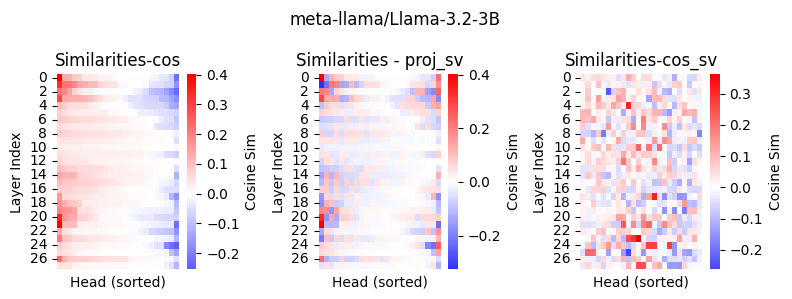

['model.layers.0.self_attn.o_proj', 'model.layers.1.self_attn.o_proj', 'model.layers.10.self_attn.o_proj', 'model.layers.11.self_attn.o_proj', 'model.layers.12.self_attn.o_proj', 'model.layers.13.self_attn.o_proj', 'model.layers.14.self_attn.o_proj', 'model.layers.15.self_attn.o_proj', 'model.layers.16.self_attn.o_proj', 'model.layers.17.self_attn.o_proj', 'model.layers.18.self_attn.o_proj', 'model.layers.19.self_attn.o_proj', 'model.layers.2.self_attn.o_proj', 'model.layers.20.self_attn.o_proj', 'model.layers.21.self_attn.o_proj', 'model.layers.22.self_attn.o_proj', 'model.layers.23.self_attn.o_proj', 'model.layers.24.self_attn.o_proj', 'model.layers.25.self_attn.o_proj', 'model.layers.26.self_attn.o_proj', 'model.layers.27.self_attn.o_proj', 'model.layers.3.self_attn.o_proj', 'model.layers.4.self_attn.o_proj', 'model.layers.5.self_attn.o_proj', 'model.layers.6.self_attn.o_proj', 'model.layers.7.self_attn.o_proj', 'model.layers.8.self_attn.o_proj', 'model.layers.9.self_attn.o_proj']
t

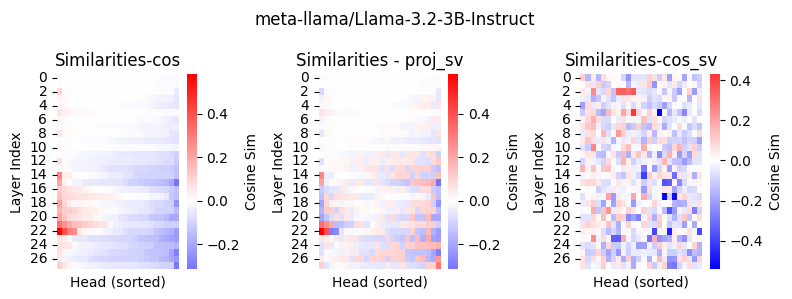

['model.layers.0.self_attn.o_proj', 'model.layers.1.self_attn.o_proj', 'model.layers.10.self_attn.o_proj', 'model.layers.11.self_attn.o_proj', 'model.layers.12.self_attn.o_proj', 'model.layers.13.self_attn.o_proj', 'model.layers.14.self_attn.o_proj', 'model.layers.15.self_attn.o_proj', 'model.layers.16.self_attn.o_proj', 'model.layers.17.self_attn.o_proj', 'model.layers.18.self_attn.o_proj', 'model.layers.19.self_attn.o_proj', 'model.layers.2.self_attn.o_proj', 'model.layers.20.self_attn.o_proj', 'model.layers.21.self_attn.o_proj', 'model.layers.22.self_attn.o_proj', 'model.layers.23.self_attn.o_proj', 'model.layers.24.self_attn.o_proj', 'model.layers.25.self_attn.o_proj', 'model.layers.3.self_attn.o_proj', 'model.layers.4.self_attn.o_proj', 'model.layers.5.self_attn.o_proj', 'model.layers.6.self_attn.o_proj', 'model.layers.7.self_attn.o_proj', 'model.layers.8.self_attn.o_proj', 'model.layers.9.self_attn.o_proj']
torch.Size([8]) torch.Size([8]) torch.Size([8])
torch.Size([8])
torch.Siz

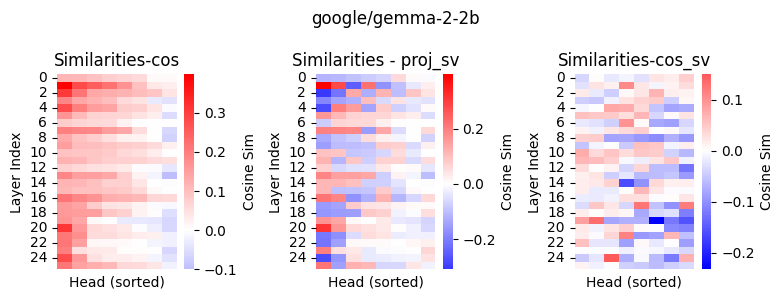

['model.layers.0.self_attn.o_proj', 'model.layers.1.self_attn.o_proj', 'model.layers.10.self_attn.o_proj', 'model.layers.11.self_attn.o_proj', 'model.layers.12.self_attn.o_proj', 'model.layers.13.self_attn.o_proj', 'model.layers.14.self_attn.o_proj', 'model.layers.15.self_attn.o_proj', 'model.layers.16.self_attn.o_proj', 'model.layers.17.self_attn.o_proj', 'model.layers.18.self_attn.o_proj', 'model.layers.19.self_attn.o_proj', 'model.layers.2.self_attn.o_proj', 'model.layers.20.self_attn.o_proj', 'model.layers.21.self_attn.o_proj', 'model.layers.22.self_attn.o_proj', 'model.layers.23.self_attn.o_proj', 'model.layers.24.self_attn.o_proj', 'model.layers.25.self_attn.o_proj', 'model.layers.3.self_attn.o_proj', 'model.layers.4.self_attn.o_proj', 'model.layers.5.self_attn.o_proj', 'model.layers.6.self_attn.o_proj', 'model.layers.7.self_attn.o_proj', 'model.layers.8.self_attn.o_proj', 'model.layers.9.self_attn.o_proj']
torch.Size([8]) torch.Size([8]) torch.Size([8])
torch.Size([8])
torch.Siz

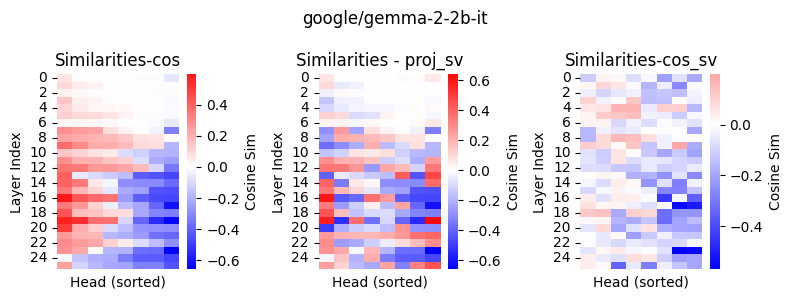

['model.layers.0.self_attn.o_proj', 'model.layers.1.self_attn.o_proj', 'model.layers.10.self_attn.o_proj', 'model.layers.11.self_attn.o_proj', 'model.layers.12.self_attn.o_proj', 'model.layers.13.self_attn.o_proj', 'model.layers.14.self_attn.o_proj', 'model.layers.15.self_attn.o_proj', 'model.layers.16.self_attn.o_proj', 'model.layers.17.self_attn.o_proj', 'model.layers.18.self_attn.o_proj', 'model.layers.19.self_attn.o_proj', 'model.layers.2.self_attn.o_proj', 'model.layers.20.self_attn.o_proj', 'model.layers.21.self_attn.o_proj', 'model.layers.22.self_attn.o_proj', 'model.layers.23.self_attn.o_proj', 'model.layers.24.self_attn.o_proj', 'model.layers.25.self_attn.o_proj', 'model.layers.26.self_attn.o_proj', 'model.layers.27.self_attn.o_proj', 'model.layers.28.self_attn.o_proj', 'model.layers.29.self_attn.o_proj', 'model.layers.3.self_attn.o_proj', 'model.layers.30.self_attn.o_proj', 'model.layers.31.self_attn.o_proj', 'model.layers.32.self_attn.o_proj', 'model.layers.33.self_attn.o_pr

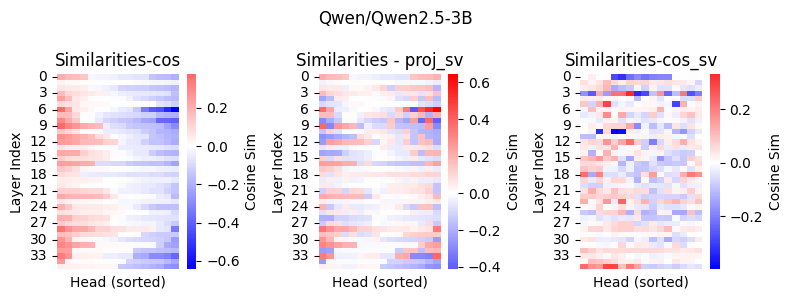

['model.layers.0.self_attn.o_proj', 'model.layers.1.self_attn.o_proj', 'model.layers.10.self_attn.o_proj', 'model.layers.11.self_attn.o_proj', 'model.layers.12.self_attn.o_proj', 'model.layers.13.self_attn.o_proj', 'model.layers.14.self_attn.o_proj', 'model.layers.15.self_attn.o_proj', 'model.layers.16.self_attn.o_proj', 'model.layers.17.self_attn.o_proj', 'model.layers.18.self_attn.o_proj', 'model.layers.19.self_attn.o_proj', 'model.layers.2.self_attn.o_proj', 'model.layers.20.self_attn.o_proj', 'model.layers.21.self_attn.o_proj', 'model.layers.22.self_attn.o_proj', 'model.layers.23.self_attn.o_proj', 'model.layers.24.self_attn.o_proj', 'model.layers.25.self_attn.o_proj', 'model.layers.26.self_attn.o_proj', 'model.layers.27.self_attn.o_proj', 'model.layers.28.self_attn.o_proj', 'model.layers.29.self_attn.o_proj', 'model.layers.3.self_attn.o_proj', 'model.layers.30.self_attn.o_proj', 'model.layers.31.self_attn.o_proj', 'model.layers.32.self_attn.o_proj', 'model.layers.33.self_attn.o_pr

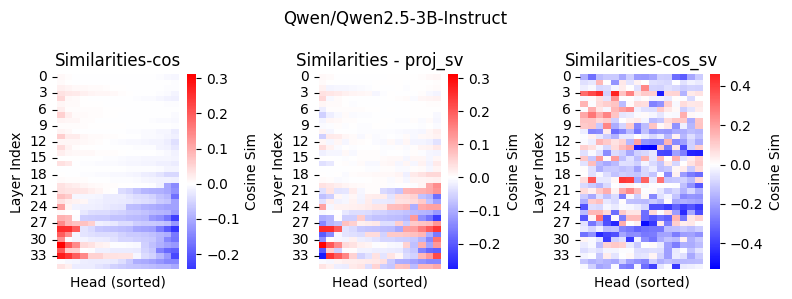

['model.layers.0.self_attn.o_proj', 'model.layers.1.self_attn.o_proj', 'model.layers.10.self_attn.o_proj', 'model.layers.11.self_attn.o_proj', 'model.layers.12.self_attn.o_proj', 'model.layers.13.self_attn.o_proj', 'model.layers.14.self_attn.o_proj', 'model.layers.15.self_attn.o_proj', 'model.layers.2.self_attn.o_proj', 'model.layers.3.self_attn.o_proj', 'model.layers.4.self_attn.o_proj', 'model.layers.5.self_attn.o_proj', 'model.layers.6.self_attn.o_proj', 'model.layers.7.self_attn.o_proj', 'model.layers.8.self_attn.o_proj', 'model.layers.9.self_attn.o_proj']
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Si

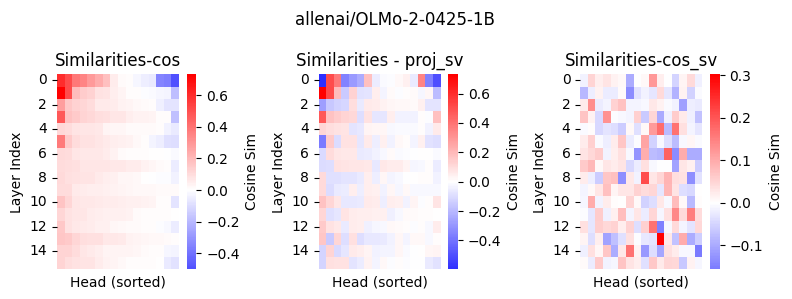

['model.layers.0.self_attn.o_proj', 'model.layers.1.self_attn.o_proj', 'model.layers.10.self_attn.o_proj', 'model.layers.11.self_attn.o_proj', 'model.layers.12.self_attn.o_proj', 'model.layers.13.self_attn.o_proj', 'model.layers.14.self_attn.o_proj', 'model.layers.15.self_attn.o_proj', 'model.layers.2.self_attn.o_proj', 'model.layers.3.self_attn.o_proj', 'model.layers.4.self_attn.o_proj', 'model.layers.5.self_attn.o_proj', 'model.layers.6.self_attn.o_proj', 'model.layers.7.self_attn.o_proj', 'model.layers.8.self_attn.o_proj', 'model.layers.9.self_attn.o_proj']
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Size([16]) torch.Size([16])
torch.Size([16])
torch.Size([16]) torch.Si

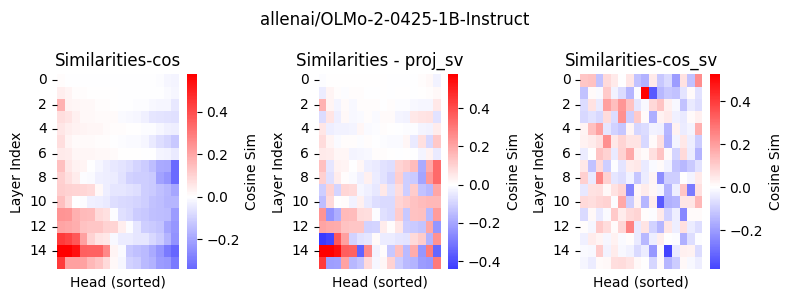

In [7]:
models = [ "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "google/gemma-2-2b-it",
          "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]


for model_name in models:
    output_dir = "/data/erblina/Master_thesis"
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model_name)
    save_path = os.path.join(output_dir, safe_model_name)
   
    atten_tensors = load_safetensors(
        os.path.join(save_path, f"attention_states_pure.safetensors")
    )
    
    labels_before = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    layer_heads = {}
    all_head_data = []
    # if tox_dir not in ['pca', 'mean_head', 'diff']:
    #     tox_dir = 'mean'
    print(list(atten_tensors.keys()))
    layer_names = sorted(list(atten_tensors.keys()), key=lambda x: int(x.split('.')[2]))
    data_norm = []
    data_cos = []
    data_3 = []
    for layer_name in layer_names:
        if layer_name not in layer_heads:
            layer_heads[layer_name] = {}

        overall_mean = atten_tensors[layer_name].float().mean(dim=0)
        toxic_behaviour = atten_tensors[layer_name][labels_before==1].float().mean(dim=0)  # (num_heads, head_dim)
        non_toxic_behaviour = atten_tensors[layer_name][labels_before==0].float().mean(dim=0)  # (num_heads, head_dim)
        head_diff = toxic_behaviour - non_toxic_behaviour  # (num_heads, head_dim)

        sign = toxic_behaviour.norm(dim=-1) - non_toxic_behaviour.norm(dim=-1)
        # sign = toxic_behaviour.amax(dim=-1) - non_toxic_behaviour.amax(dim=-1)
        sign_ = torch.sign(sign)
        signed_scores_2 = 1 - F.cosine_similarity(toxic_behaviour, non_toxic_behaviour, dim=-1)  # non_toxic_behaviour, dim=-1) #[num_heads]
        signed_scores2 = signed_scores_2 * sign_
        data_norm.append(signed_scores2.float().numpy())


        
        r = toxic_behaviour.amax(0) - non_toxic_behaviour.amax(0)      # reference direction
        # r = toxic_behaviour - non_toxic_behaviour
        sims = F.cosine_similarity(atten_tensors[layer_name].float(), r.unsqueeze(0), dim=-1)
        signed_scores1 = sims.mean(0) 

        # signed_scores = signed_scores * sign_
        data_cos.append(signed_scores1.float().numpy())
        print(signed_scores1.shape, signed_scores_2.shape, sign_.shape)

        
        
        
        # print(d_3.shape)
        r = toxic_behaviour.mean(0) - non_toxic_behaviour.mean(0)      # reference direction
        sims = F.cosine_similarity(atten_tensors[layer_name].float(), r.unsqueeze(0), dim=-1)
        ar_max = torch.argmax(abs(sims), dim=0)
        signed_scores = sims[ar_max] #.mean(0)
        sign = torch.sign(signed_scores1)
        print(sign.shape)
        sign2 = (sign == sign_) * sign

        d_3 = signed_scores #* sign2
        # data_3.append(d_3.float().numpy())

        u = F.normalize(toxic_behaviour.amax(0) - non_toxic_behaviour.amax(0), dim=0)   # [D]

        sign = torch.sign(((toxic_behaviour - non_toxic_behaviour) @ u))  # [H]
        # Distance to overall mean as magnitude:
        mag  = overall_mean @ u.T #F.cosine_similarity(u, overall_mean, dim=-1)        # [H]
        signed_scores = mag #* sign                # [H]
        # data_3.append(signed_scores.float().numpy())
        # sign = toxic_behaviour.norm(dim=-1) - non_toxic_behaviour.norm(dim=-1)
        # # sign = toxic_behaviour.amax(dim=-1) - non_toxic_behaviour.amax(dim=-1)
        # sign_ = torch.sign(sign)
        # signed_scores_2 = 1 - F.cosine_similarity(toxic_behaviour, non_toxic_behaviour, dim=-1)  # non_toxic_behaviour, dim=-1) #[num_heads]
        # signed_scores2 = signed_scores_2 * sign_
        # data_norm.append(signed_scores2.float().numpy())
        # data_3.append(signed_scores2.float().numpy())
        # data_cos.append(signed_scores.float().numpy())
        u = (toxic_behaviour - non_toxic_behaviour).norm(dim=0)   # [head_dim]
        u = F.normalize(u, dim=0)                                 # unit vector

        # ---- 2. Per-head difference
        head_diffs = toxic_behaviour - non_toxic_behaviour         # [num_heads, head_dim]

        # ---- 3. Sign: whether each head’s difference aligns with the global direction
        sign_h = torch.sign(torch.matmul(head_diffs, u))           # [num_heads]

        # ---- 4. Magnitude: cosine distance between toxic and non-toxic means per head
        mag_h = 1 - F.cosine_similarity(toxic_behaviour, non_toxic_behaviour, dim=-1)  # [num_heads]

        # ---- 5. Final signed score
        score_h = sign_h * mag_h   

        data_3.append(score_h.float().numpy())
        
        

    data_norm = np.array(data_norm)  # (num_layers, num_heads)
    data_cos = np.array(data_cos)    # (num_layers, num_heads)
    data_3 = np.array(data_3)
    print(data_3.shape, data_cos.shape, data_norm.shape)
    data_norm_i = np.argsort(data_norm, axis=1)[:, ::-1]
    data_cos_i  = np.argsort(data_cos, axis=1)[:, ::-1]
    data_cos = np.take_along_axis(data_cos, data_norm_i, axis=1)
    data_norm = np.take_along_axis(data_norm, data_norm_i, axis=1)
    data_3 = np.take_along_axis(data_3, data_norm_i, axis=1)

    plt.figure(figsize=(8,3))
    plt.subplot(1,3,1)
    sns.heatmap(data_norm, cmap='bwr', center=0, cbar_kws={'label': 'Cosine Sim'})
    plt.title(f"Similarities-cos")
    plt.xlabel("Head (sorted)")
    plt.ylabel("Layer Index")
    plt.yticks(rotation=0)
    plt.xticks([])
    plt.subplot(1,3,2)
    sns.heatmap(data_3, cmap='bwr', center=0, cbar_kws={'label': 'Cosine Sim'})
    plt.title(f"Similarities - proj_sv")
    plt.xlabel("Head (sorted)")
    plt.ylabel("Layer Index")   
    plt.yticks(rotation=0)
    plt.xticks([])
    plt.subplot(1,3,3)
    sns.heatmap(data_cos, cmap='bwr', center=0, cbar_kws={'label': 'Cosine Sim'})
    plt.title(f"Similarities-cos_sv")
    plt.xlabel("Head (sorted)")
    plt.ylabel("Layer Index")
    plt.yticks(rotation=0)
    plt.xticks([])
    plt.suptitle(f"{model_name}")
    plt.tight_layout()
    plt.show()



[[0.18524621]]


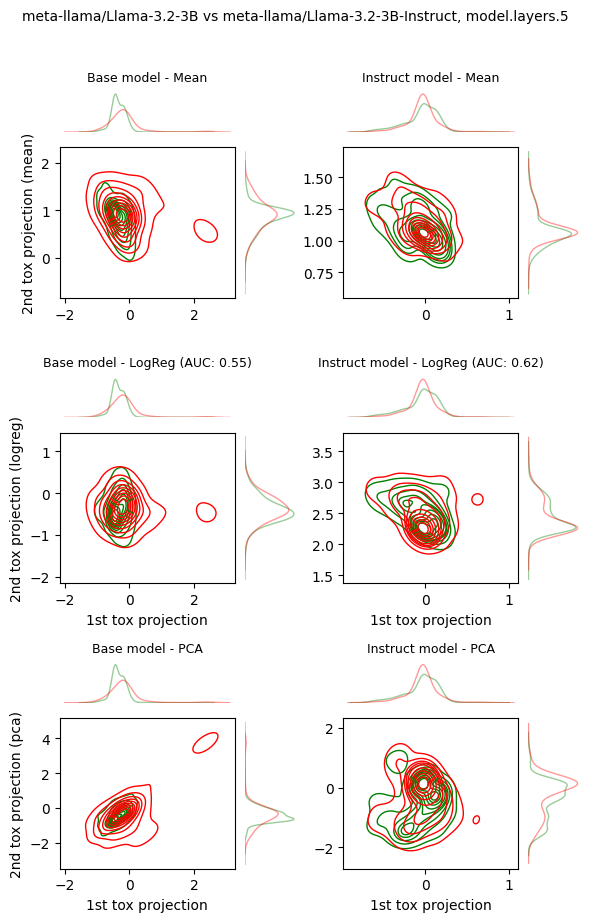

[[-0.06663382]]


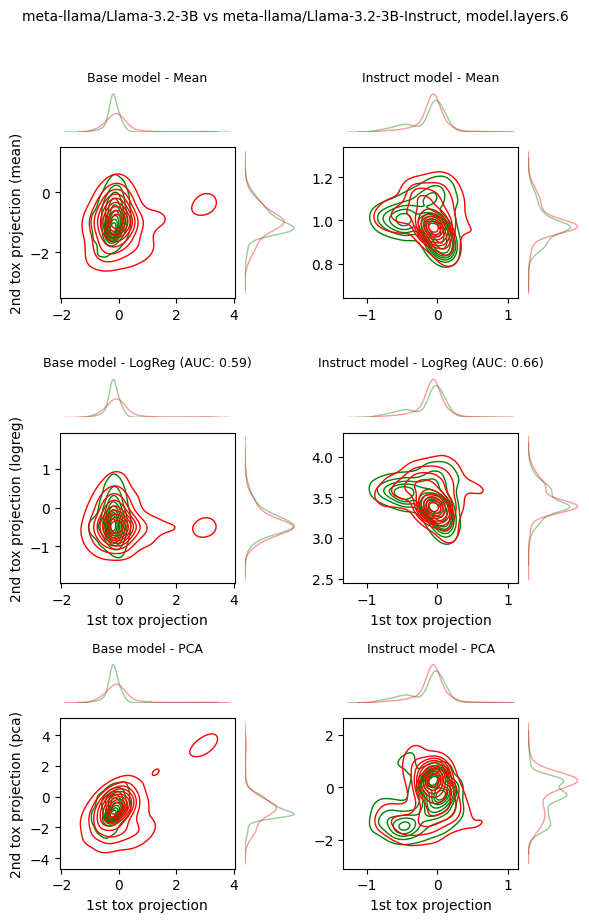

[[-0.02786635]]


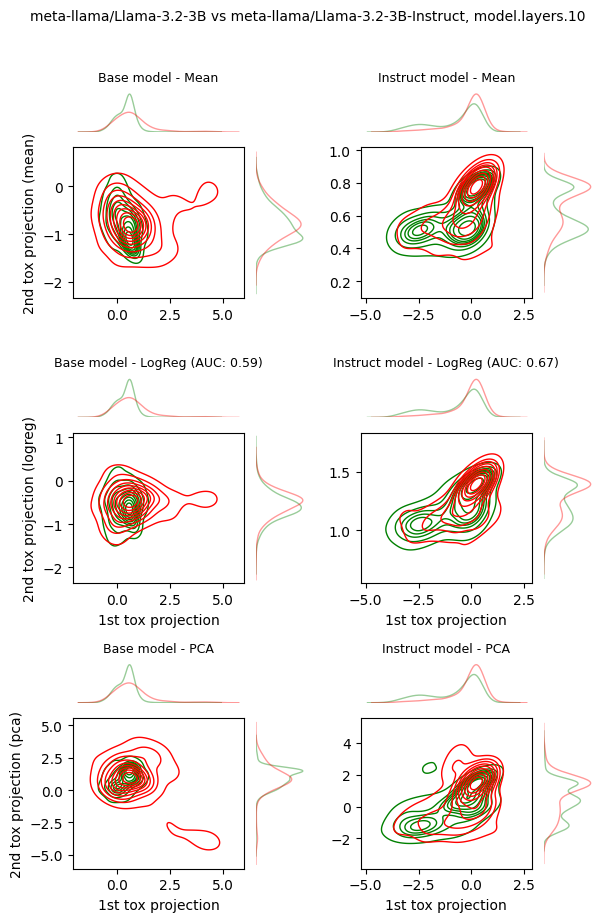

[[0.09401843]]


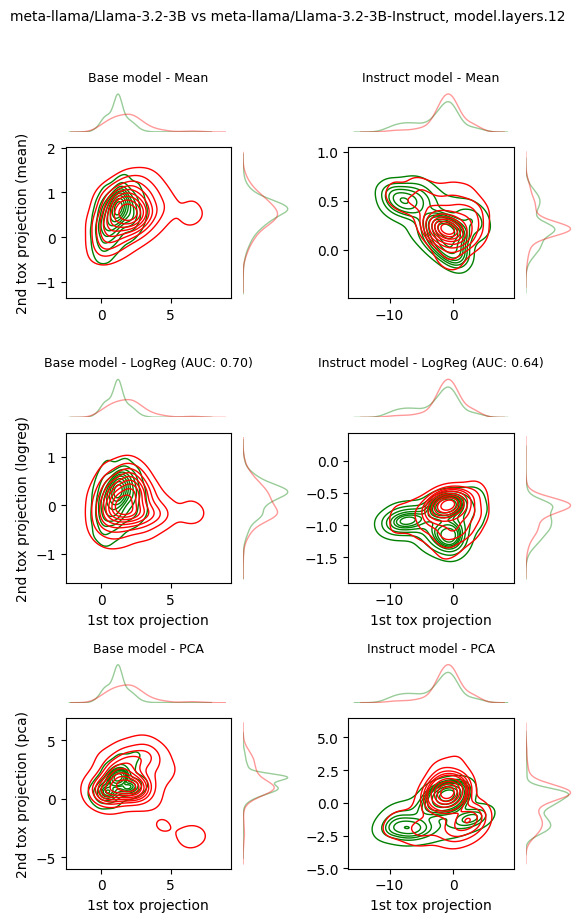

[[-0.0732674]]


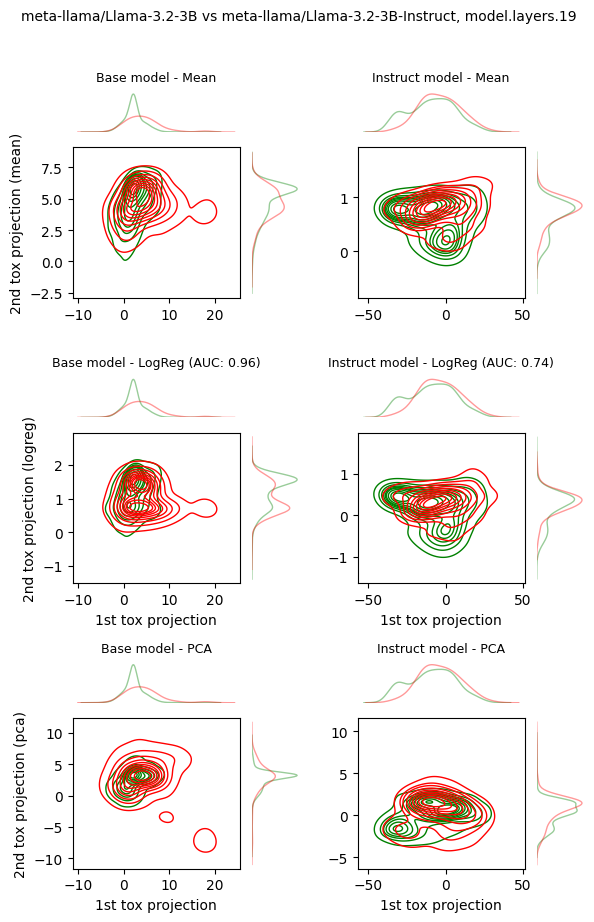

[[-0.02075308]]


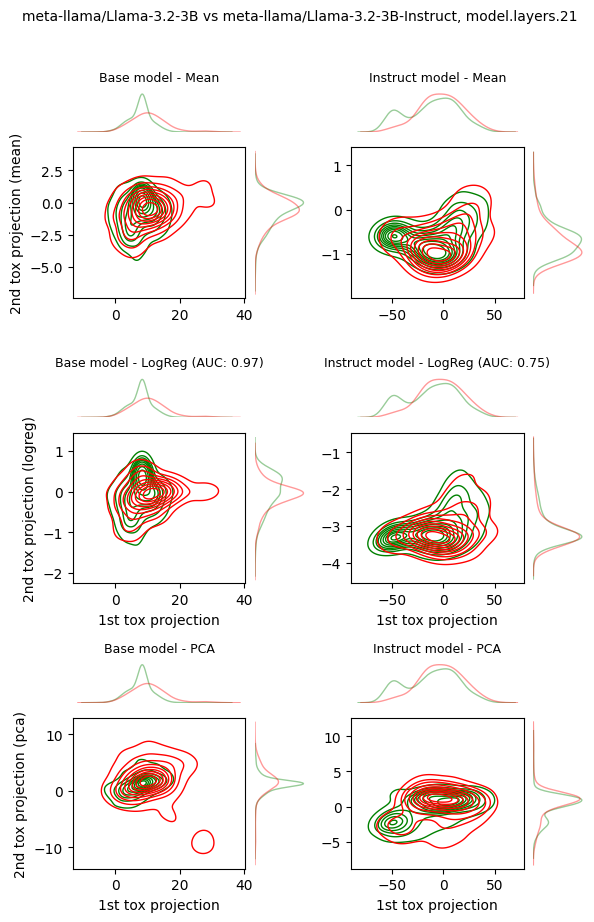

[[-0.06212262]]


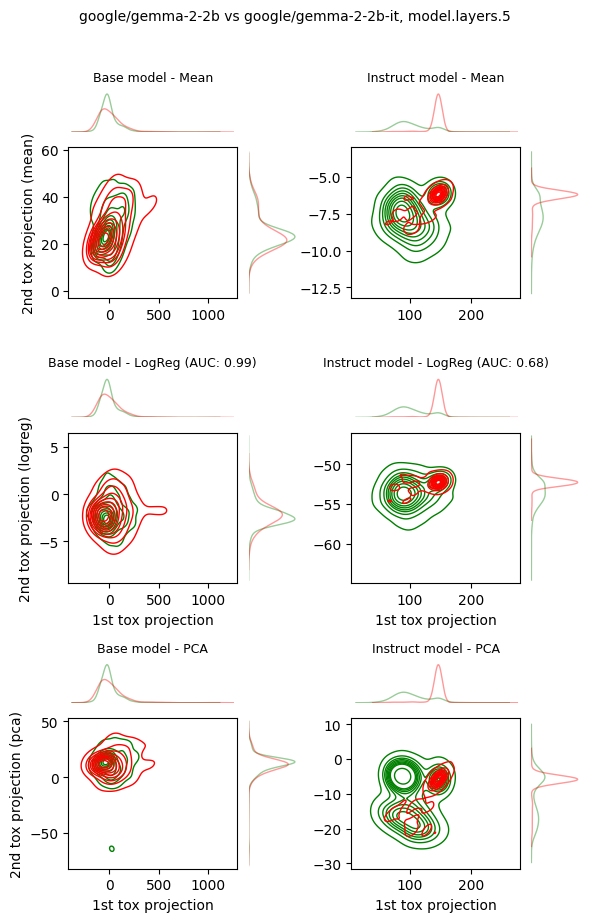

[[0.17456036]]


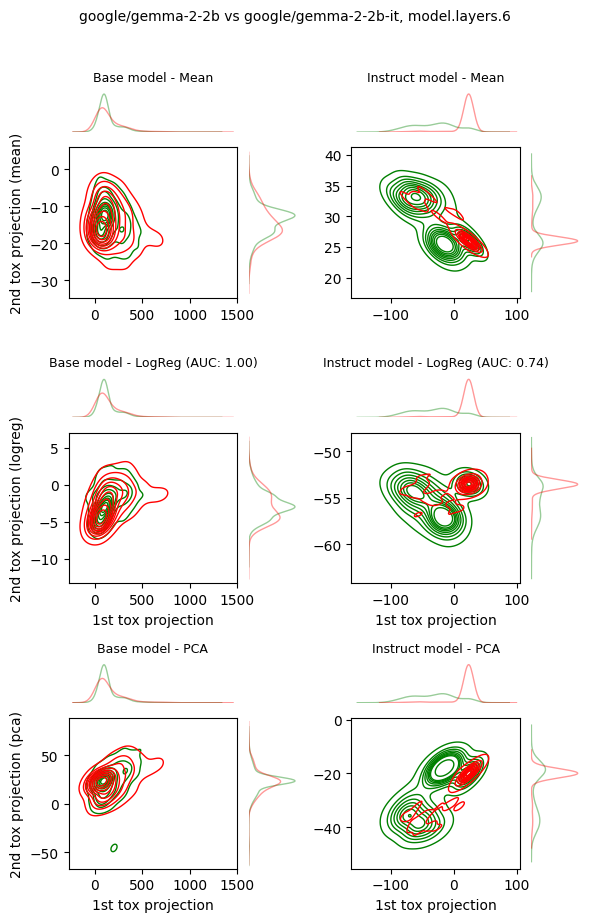

[[0.01014948]]


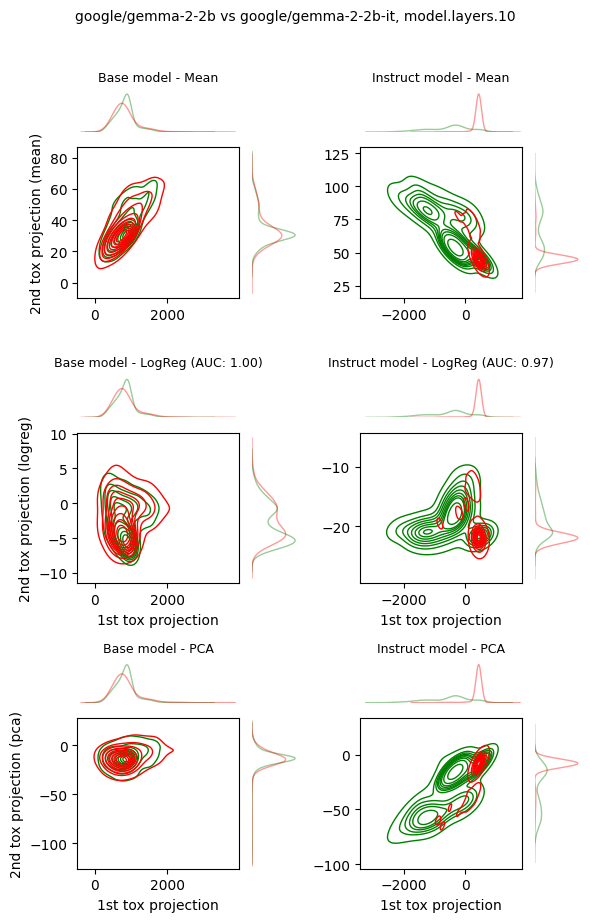

[[-0.07578898]]


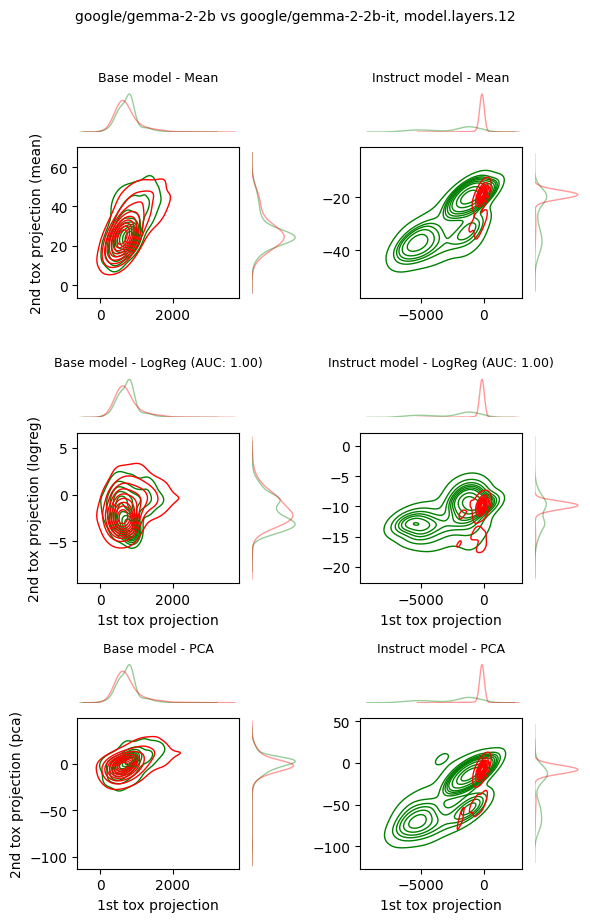

[[0.10538183]]


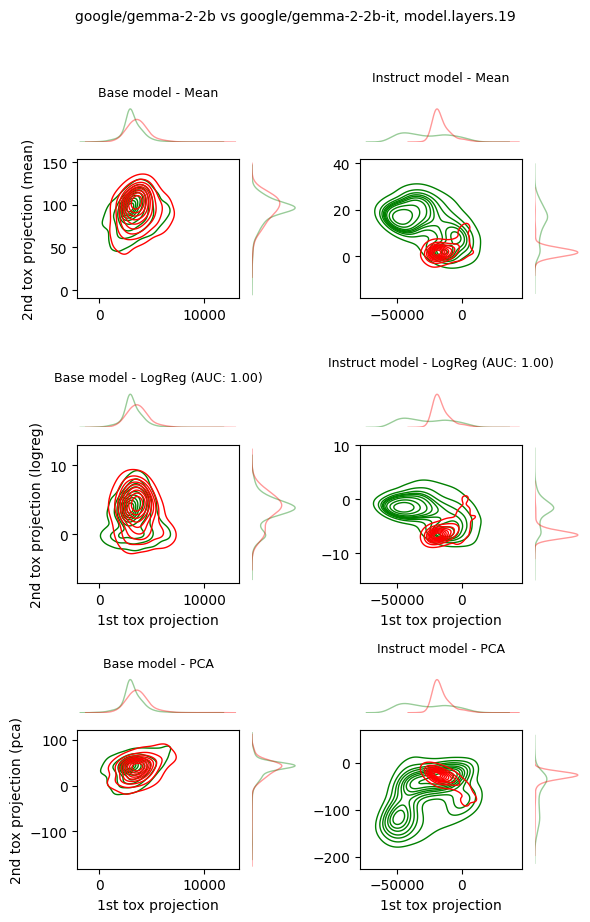

[[0.033757]]


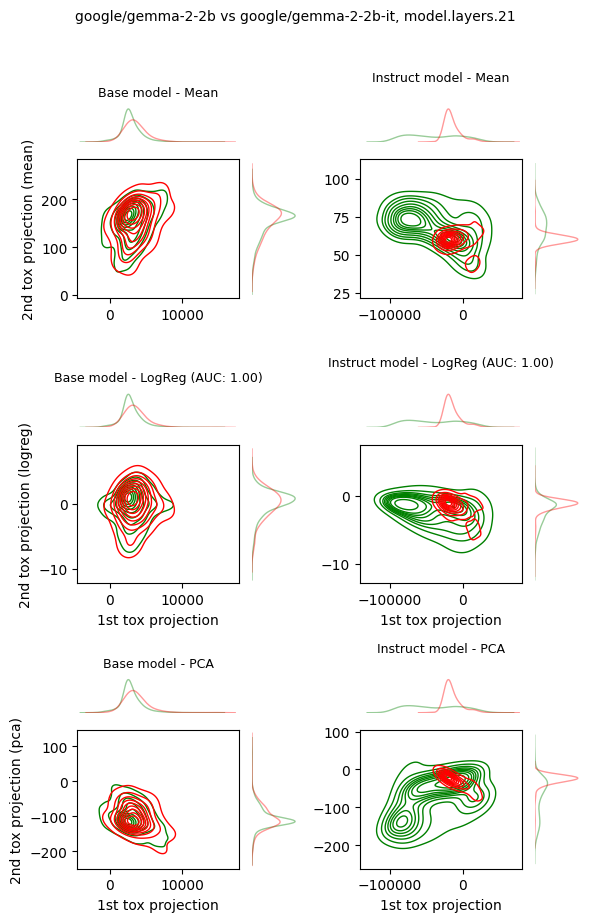

[[0.00030739]]


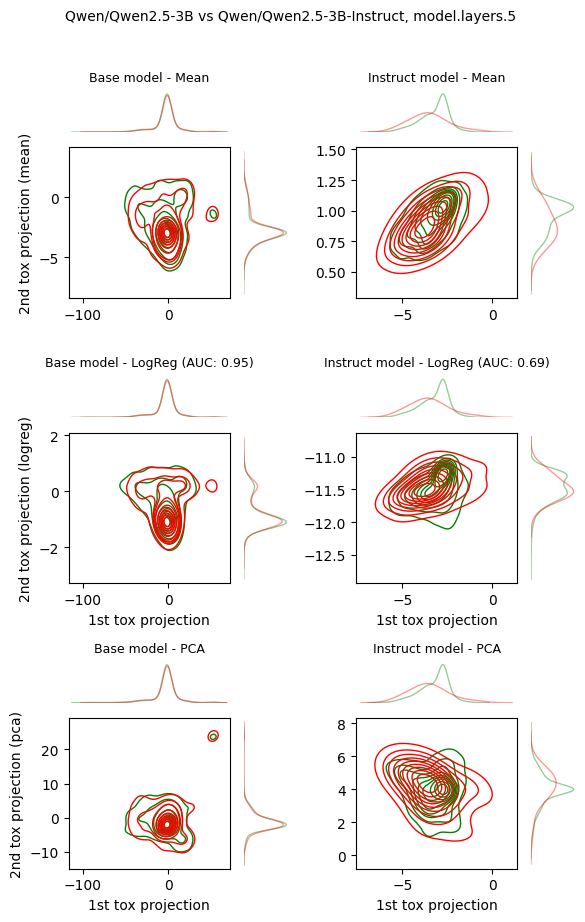

[[0.056548]]


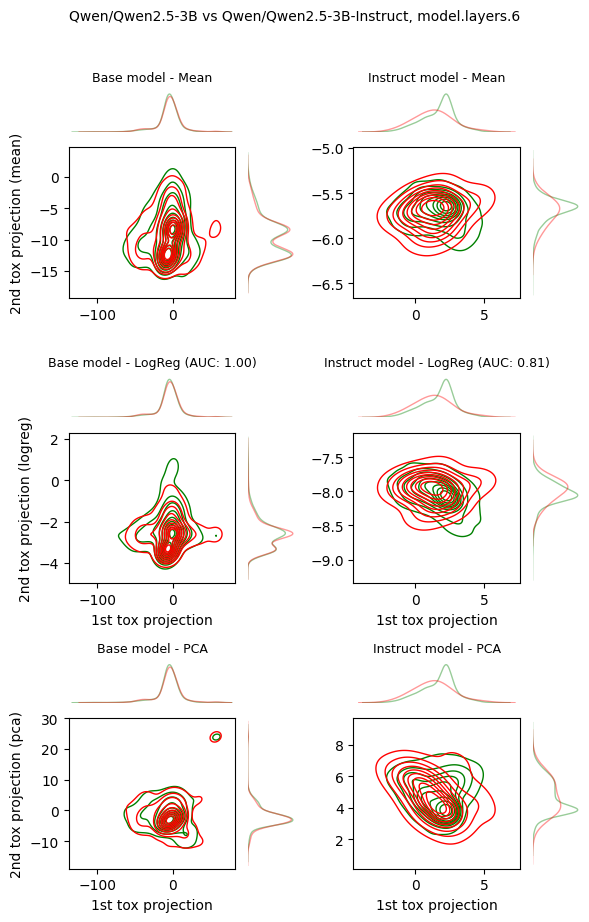

[[-0.22084986]]


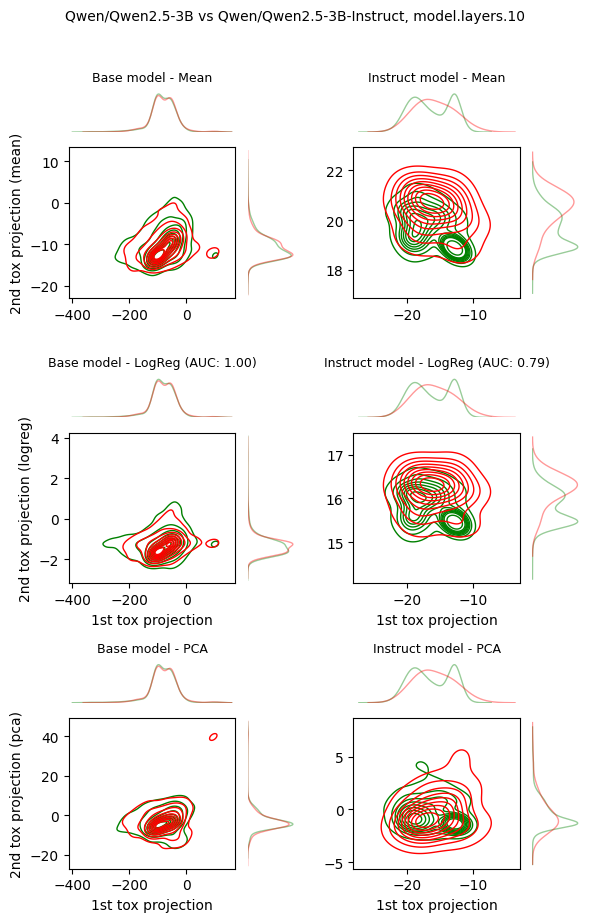

[[0.39421102]]


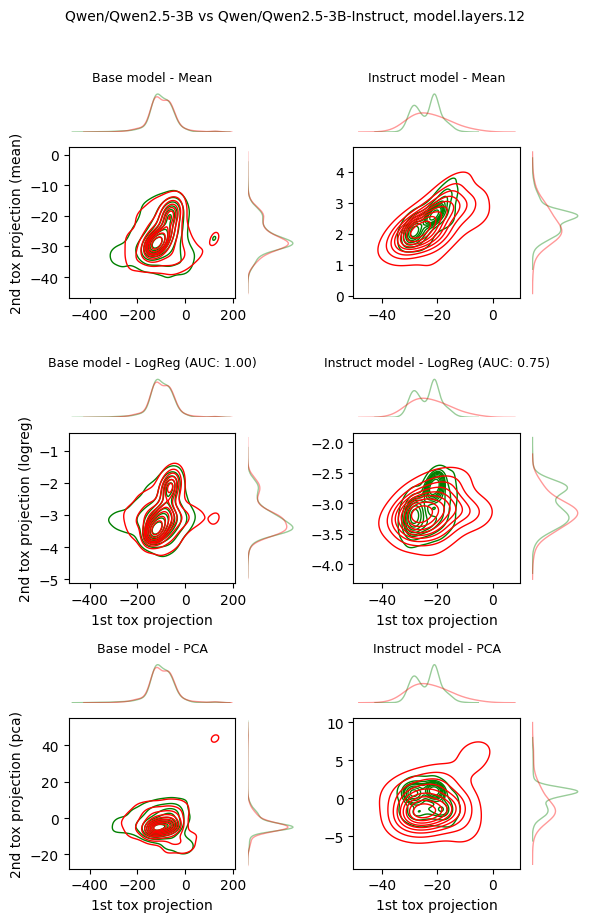

[[0.22948385]]


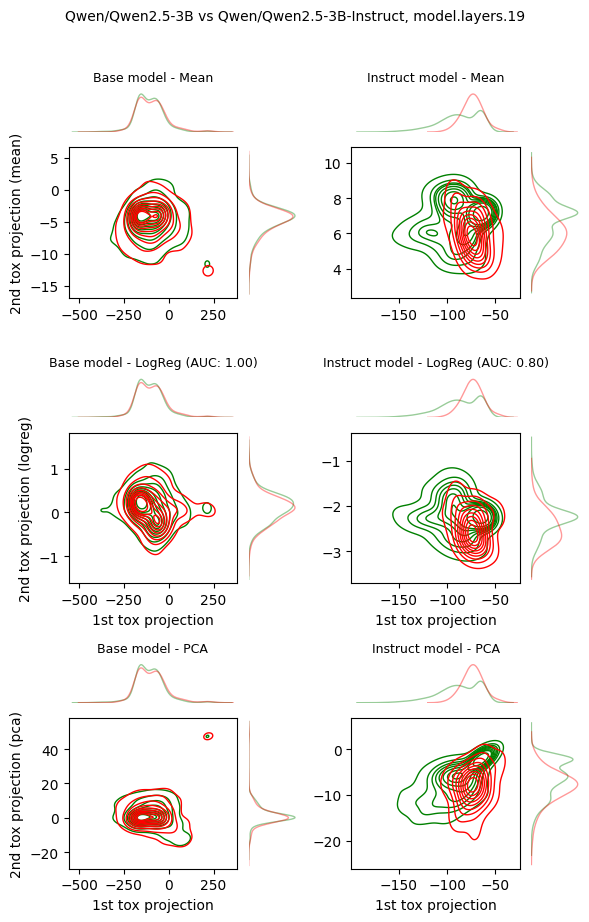

[[-0.02552222]]


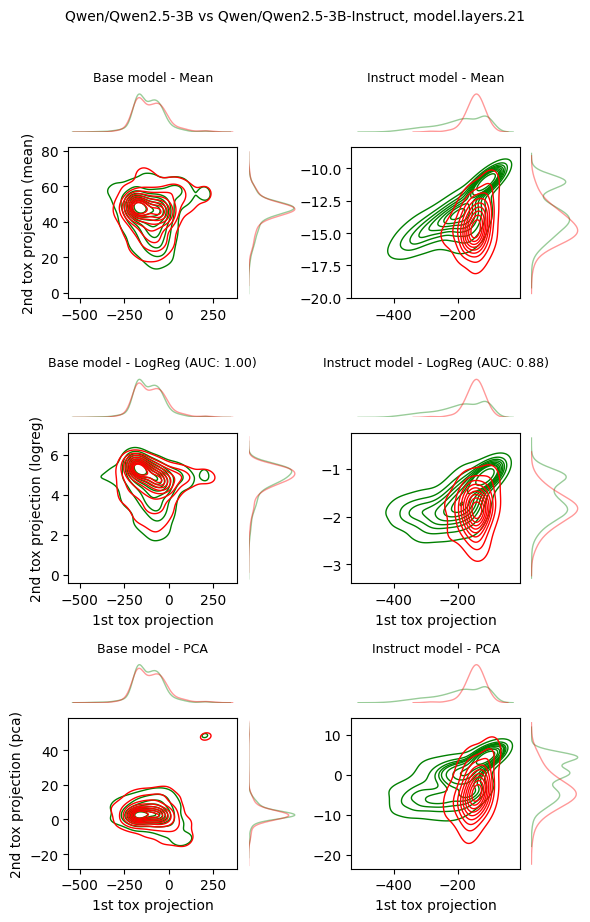

[[-0.0084344]]


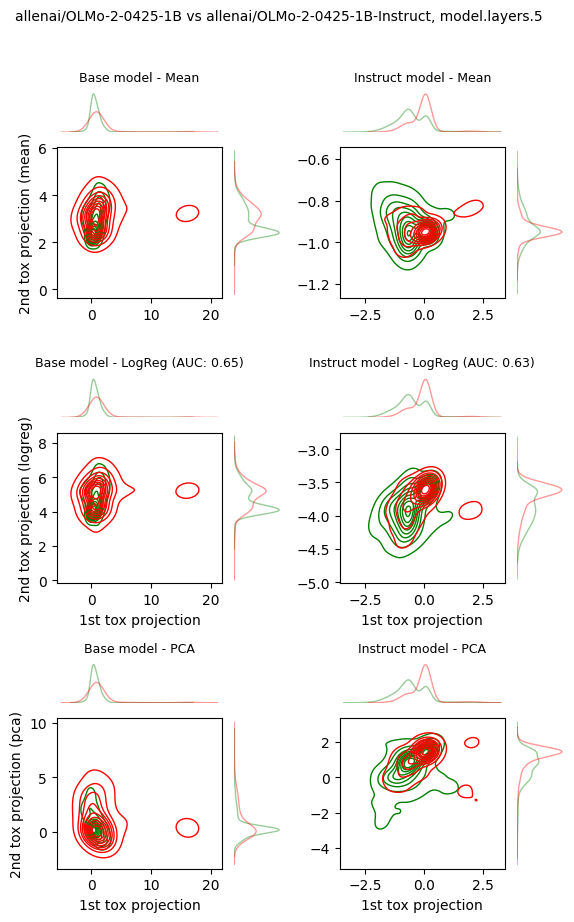

[[0.00894512]]


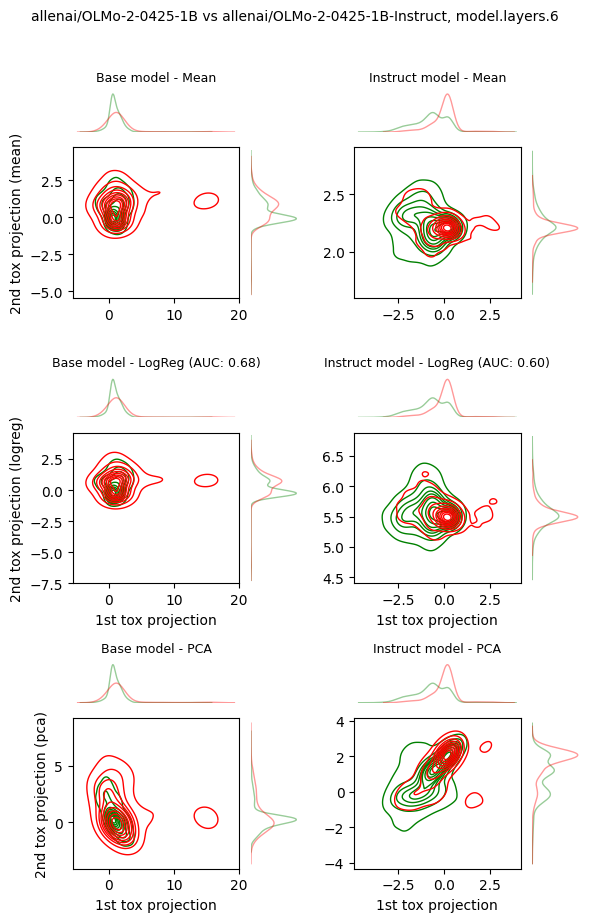

[[0.01836004]]


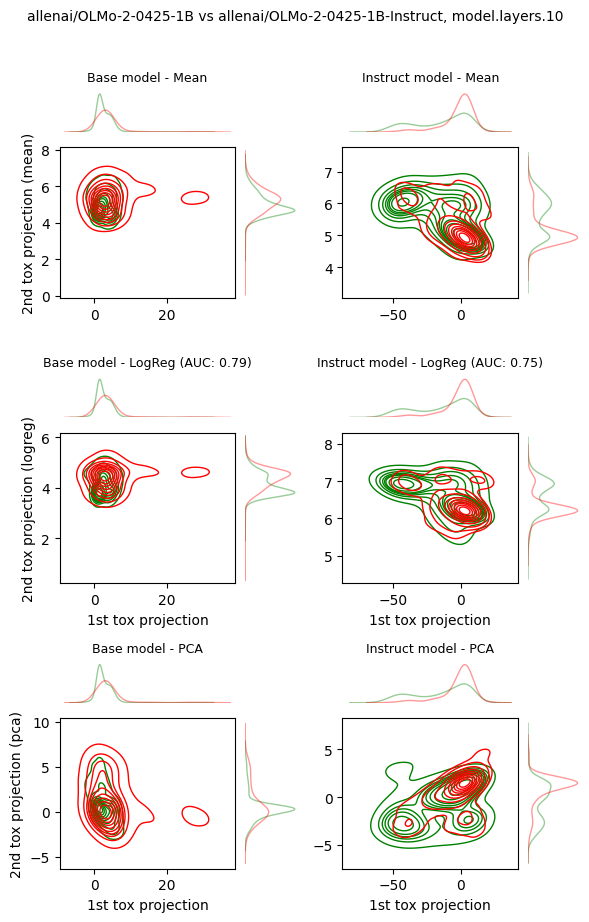

[[0.03103509]]


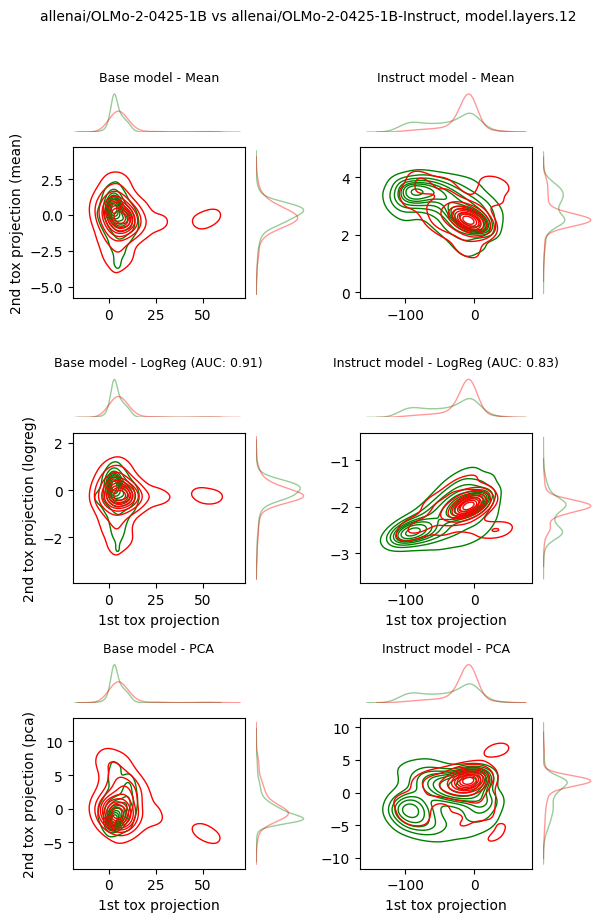

In [23]:
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_kde_panel_with_marginals(fig, outer_position, x1, x2, y,
                                  title="", xlabel="", ylabel=""):
    """
    Draw a single panel (with top/right marginals) inside a 2x2 outer layout.
    """
    # Create a nested gridspec inside the given outer cell
    outer = fig.add_gridspec(3, 2)
    gs = outer[outer_position[0], outer_position[1]].subgridspec(4, 4)

    # Central 2D KDE
    ax_joint = fig.add_subplot(gs[1:,:-1])
    ax_marg_x = fig.add_subplot(gs[0,:-1], sharex=ax_joint)
    ax_marg_y = fig.add_subplot(gs[1:,-1], sharey=ax_joint)

    # Plot both classes
    for label, color in zip([0,1], ['green', 'red']):
        sns.kdeplot(x=x1[y==label], y=x2[y==label],
                    ax=ax_joint, fill=False, color=color, levels=10, linewidths=1, bw_adjust=1.5)
        sns.kdeplot(x=x1[y==label], ax=ax_marg_x,
                    fill=False, alpha=0.4, color=color, linewidth=1, bw_adjust=1.5)
        sns.kdeplot(y=x2[y==label], ax=ax_marg_y,
                    fill=False, alpha=0.4, color=color, linewidth=1, bw_adjust=1.5)

    # Hide tick labels for marginals
    plt.setp(ax_marg_x.get_xticklabels(), visible=False)
    plt.setp(ax_marg_y.get_yticklabels(), visible=False)
    #  Remove tick labels and axis boxes for marginals
    ax_marg_x.set_axis_off()
    ax_marg_y.set_axis_off()

    # Labels & title
    ax_joint.set_xlabel(xlabel)
    ax_joint.set_ylabel(ylabel)
    # ax_joint.set_title(title, fontsize=9)
    ax_marg_x.set_title(title, fontsize=9, pad=8)




    # Tighten layout within each panel
    plt.tight_layout(pad=0.3)
    # Labels & title

    return ax_joint  # return central axis if needed


models = [( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
          ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]


def get_second_dir(X,y,  w, method='mean'):
    # normalize w
    w1 = w / (np.linalg.norm(w) + 1e-12)

    # projector onto orthogonal complement
    P_perp = np.eye(w1.size) - np.outer(w1, w1)
    if method == 'mean':

        Xp = X @ P_perp
        mu1 = Xp[y==1].mean(0)
        mu0 = Xp[y==0].mean(0)
        w2 = mu1 - mu0            # residual mean diff
        n = np.linalg.norm(w2) + 1e-12
        w2 = w2 / n
        auc = np.nan
    elif method == 'pca':
        Xc = X - X.mean(axis=0, keepdims=True)     # center data
        w1 = w / np.linalg.norm(w)

        # --- find new direction orthogonal to w with largest variance ---
        # deflate along w
        X_res = Xc - np.outer(Xc @ w1, w1)

        # SVD of the residual data
        _, _, Vt = np.linalg.svd(X_res, full_matrices=False)
        w2 = Vt[0]  
        auc = np.nan
    else:
        X_perp = X @ P_perp
        clf = LogisticRegression(max_iter=2000).fit(X_perp, y)
        w2 = clf.coef_.ravel()
        w2 = w2 / (np.linalg.norm(w2) + 1e-12)
        yhat = clf.predict(X_perp)
        auc = balanced_accuracy_score(y, yhat)
        auc = roc_auc_score(y, clf.decision_function(X_perp))

        w2_res = clf.coef_.ravel()
        w2_orig = P_perp @ w2_res
        w2 /= (np.linalg.norm(w2_orig) + 1e-12)

    return w2, auc

for pair in models:
    
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))
    yb = (v1b > 0).astype(int)
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    yi = (v1i > 0).astype(int)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))

    X_datab = []
    y_datab = []
    X_datai = []
    y_datai = []

    for data in datasets_list:
        X_d_b, y_d_b = load_datasets(model_base, data, output_dir)
        y_d_b = (y_d_b > 0).astype(int)
        X_datab.append(X_d_b)
        y_datab.append(y_d_b)

        X_d_i, y_d_i = load_datasets(model_it, data, output_dir)
        y_d_i = (y_d_i > 0).astype(int)
        X_datai.append(X_d_i)
        y_datai.append(y_d_i)


    t = 'toxic'
    res_base = {}
    res_it = {}
    layer_names = [layer for layer in layer_names if int(layer.split('.')[-1]) in [5, 19, 21, 10, 12, 6]]
    for i, layer in enumerate(layer_names):
        res_base[layer] = {}
        res_it[layer] = {}
        X_allb = []
        y_allb = []
        X_alli = []
        y_alli = []

        X_allb.append(X_1b[layer].float().numpy())
        y_allb.append(yb)
        X_alli.append(X_1i[layer].float().numpy())
        y_alli.append(yi)

        for data in X_datab:
            X_allb.append(data[layer].float().numpy())
        for labels in y_datab:
            y_allb.append(labels)

        for data in X_datai:
            X_alli.append(data[layer].float().numpy())
        for labels in y_datai:
            y_alli.append(labels)
        
        X_allb = np.concatenate(X_allb, axis=0)
        y_allb = np.concatenate(y_allb, axis=0)
        X_alli = np.concatenate(X_alli, axis=0)
        y_alli = np.concatenate(y_alli, axis=0)

        for method in ['mean', 'logreg', 'pca']:
            res_base[layer][method] = []
            res_it[layer][method] = []

        for method in ['mean', 'pca', 'logreg']:
            # Get first steering vector
            w1_b = steering_vector_a[layer][t].float().numpy()
            w1_it= steering_vector_b[layer][t].float().numpy()

            # Get second steering vector
            w2_base, auc_base = get_second_dir(X_1b[layer].float().numpy(), yb, w1_b, method=method)
            w2_it, auc_it = get_second_dir(X_1i[layer].float().numpy(), yi, w1_it, method=method)

            # Compute cosine similarity between the two second directions
            # x1_b = X_1b[layer].float().numpy() @ w1_b
            # x2_b = X_1b[layer].float().numpy() @ w2_base
            # x1_i = X_1i[layer].float().numpy() @ w1_it
            # x2_i = X_1i[layer].float().numpy() @ w2_it
            x1_b = X_allb @ w1_b
            x2_b = X_allb @ w2_base
            x1_i = X_alli @ w1_it
            x2_i = X_alli @ w2_it
            # print(x2_i.shape)

            res_base[layer][method].append((x1_b, x2_b))
            # print(res_base[layer][method][-1][0].shape)
            res_it[layer][method].append((x1_i, x2_i))
        
        print(cosine_similarity(w2_base.reshape(1,-1), w2_it.reshape(1,-1)))

        
        fig = plt.figure(figsize=(6,9))

        # (1) Base model - Mean
        x1 = res_base[layer]['mean'][-1]
        plot_kde_panel_with_marginals(
            fig, (0,0), x1[0], x1[1], y_allb,
            title="Base model - Mean",
            ylabel="2nd tox projection (mean)"
        )

        # (2) Instruct model - Mean
        x1 = res_it[layer]['mean'][-1]
        plot_kde_panel_with_marginals(
            fig, (0,1), x1[0], x1[1], y_alli,
            title="Instruct model - Mean"
        )

        # (3) Base model - LogReg
        x1 = res_base[layer]['logreg'][-1]
        plot_kde_panel_with_marginals(
            fig, (1,0), x1[0], x1[1], y_allb,
            title=f"Base model - LogReg (AUC: {auc_base:.2f})",
            xlabel="1st tox projection",
            ylabel="2nd tox projection (logreg)"
        )

        # (4) Instruct model - LogReg
        x1 = res_it[layer]['logreg'][-1]
        plot_kde_panel_with_marginals(
            fig, (1,1), x1[0], x1[1], y_alli,
            title=f"Instruct model - LogReg (AUC: {auc_it:.2f})",
            xlabel="1st tox projection"
        )

        # (3) Base model - LogReg
        x1 = res_base[layer]['pca'][-1]
        plot_kde_panel_with_marginals(
            fig, (2,0), x1[0], x1[1], y_allb,
            title=f"Base model - PCA",
            xlabel="1st tox projection",
            ylabel="2nd tox projection (pca)"
        )

        # (4) Instruct model - LogReg
        x1 = res_it[layer]['pca'][-1]
        plot_kde_panel_with_marginals(
            fig, (2,1), x1[0], x1[1], y_alli,
            title=f"Instruct model - PCA",
            xlabel="1st tox projection"
        )
        # plt.legend(labels=['non-toxic', 'toxic'], loc='upper right', bbox_to_anchor=(1.15, 3.2))
        fig.suptitle(f"{model_base} vs {model_it}, {layer}", fontsize=10, y=1.02)
        plt.tight_layout()
        plt.show()
        # os.makedirs(os.path.dirname(f"/home/fe/purelku/Desktop/Master_thesis/kde_panels/{safe_base}_vs_{safe_it}_{layer}_kde_panel.png"), exist_ok=True)
        # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/kde_panels/{safe_base}_vs_{safe_it}_{layer}_kde_panel.png", bbox_inches='tight', dpi=300)
        plt.close()

        # plt.figure(figsize=(6,6))

        # # ---- (1) Base model - Mean ----
        # plt.subplot(2,2,1)
        # plt.title("Base model - Mean")
        # x1 = res_base[layer]['mean'][-1]
        # sns.kdeplot(x=x1[0][yb==0], y=x1[1][yb==0],
        #             fill=False, color='green', levels=10, linewidths=1.0, label='non-toxic')
        # sns.kdeplot(x=x1[0][yb==1], y=x1[1][yb==1],
        #             fill=False, color='red', levels=10, linewidths=1.0, label='toxic')
        # plt.ylabel("2nd TOX projection (mean)")

        # # ---- (2) Instruct model - Mean ----
        # plt.subplot(2,2,2)
        # plt.title("Instruct model - Mean")
        # x1 = res_it[layer]['mean'][-1]
        # sns.kdeplot(x=x1[0][yi==0], y=x1[1][yi==0],
        #             fill=False, color='green', levels=10, linewidths=1.0, label='non-toxic')
        # sns.kdeplot(x=x1[0][yi==1], y=x1[1][yi==1],
        #             fill=False, color='red', levels=10, linewidths=1.0, label='toxic')

        # # ---- (3) Base model - LogReg ----
        # plt.subplot(2,2,3)
        # plt.title(f"Base model - LogReg (AUC: {auc_base:.2f})")
        # x1 = res_base[layer]['logreg'][-1]
        # sns.kdeplot(x=x1[0][yb==0], y=x1[1][yb==0],
        #             fill=False, color='green', levels=10, linewidths=1.0, label='non-toxic')
        # sns.kdeplot(x=x1[0][yb==1], y=x1[1][yb==1],
        #             fill=False, color='red', levels=10, linewidths=1.0, label='toxic')
        # plt.ylabel("2nd TOX projection (logreg)")
        # plt.xlabel("1st TOX projection")

        # # ---- (4) Instruct model - LogReg ----
        # plt.subplot(2,2,4)
        # plt.title(f"Instruct model - LogReg (AUC: {auc_it:.2f})")
        # x1 = res_it[layer]['logreg'][-1]
        # sns.kdeplot(x=x1[0][yi==0], y=x1[1][yi==0],
        #             fill=False, color='green', levels=10, linewidths=1.0, label='non-toxic')
        # sns.kdeplot(x=x1[0][yi==1], y=x1[1][yi==1],
        #             fill=False, color='red', levels=10, linewidths=1.0, label='toxic')
        # plt.xlabel("1st TOX projection")

        # plt.suptitle(f"{model_base} vs {model_it}, {layer}")
        # plt.tight_layout()
        # plt.show()


        # plt.figure(figsize=(6,6))
        # plt.subplot(2,2,1)
        # plt.title("Base model - Mean")
        # x1 = res_base[layer]['mean'][-1]
        # plt.scatter(x1[0][yb==1], x1[1][yb==1], color='red', alpha=0.5, label='toxic')
        # plt.scatter(x1[0][yb==0], x1[1][yb==0], color='green', alpha=0.5, label='non-toxic')
        # plt.ylabel("2nd TOX projection (mean)")
        # plt.subplot(2,2,2)
        # plt.title("Instruct model - Mean")
        # x1 = res_it[layer]['mean'][-1]
        # plt.scatter(x1[0][yi==1], x1[1][yi==1], color='red', alpha=0.5, label='toxic')
        # plt.scatter(x1[0][yi==0], x1[1][yi==0], color='green', alpha=0.5, label='non-toxic')
        # plt.subplot(2,2,3)
        # plt.title(f"Base model - LogReg (AUC: {auc_base:.2f})")
        # x1 = res_base[layer]['logreg'][-1]
        # plt.scatter(x1[0][yb==1], x1[1][yb==1], color='red', alpha=0.5, label='toxic')
        # plt.scatter(x1[0][yb==0], x1[1][yb==0], color='green', alpha=0.5, label='non-toxic')
        # plt.ylabel("2nd TOX projection (logreg)")
        # plt.xlabel("1st TOX projection")
        # plt.subplot(2,2,4)
        # plt.title(f"Instruct model - LogReg\n (AUC: {auc_it:.2f})")
        # x1 = res_it[layer]['logreg'][-1]
        # plt.scatter(x1[0][yi==1], x1[1][yi==1], color='red', alpha=0.5, label='toxic')
        # plt.scatter(x1[0][yi==0], x1[1][yi==0], color='green', alpha=0.5, label='non-toxic')
        # plt.xlabel("1st TOX projection")
        # plt.suptitle(f"{model_base} vs {model_it}, {layer}")
        # plt.show()


In [ ]:
def upper_triangle(mat):
    """Flatten the upper triangle (excluding diagonal) of a symmetric matrix."""
    if mat.size == 0:
        return np.array([])
    i, j = np.triu_indices_from(mat, k=1)
    return mat[i, j]

models = ["meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]

for model in models: 
    layers = model_steering_1[model]['layers']
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    # plt.figure(figsize=(12,8))
    for i, layer in enumerate(layers):
        
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        v1 = (v1 > 0).astype(int)
       
        X_1[layer] = F.normalize(X_1[layer], p=2, dim=1)
        print(sum(v1==1), sum(v1==0))
        X.append(X_1[layer].float().numpy())
        


        y.append(v1)
        print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)
            X.append(X_2[layer].float().numpy())
            y.append(v2)
            print(sum(v2==1), sum(v2==0))
            print(f"  Dataset: {data}, Hidden states shape: {X_2[layer].shape}, Labels shape: {v2.shape}")
           
            X_2[layer] = F.normalize(X_2[layer], p=2, dim=1)
            


        X_all = np.concatenate(X, axis=0)
        X_c = cosine_similarity(X_all)
        y_all = np.concatenate(y, axis=0)
        toxmask = (y_all==1)
        nontoxmask = (y_all==0)
        tox_block = X_c[toxmask][:, toxmask]
        nontox_block = X_c[nontoxmask][:, nontoxmask]
        between_block = X_c[toxmask][:, nontoxmask]
        cos_tox = upper_triangle(tox_block)
        cos_nontox = upper_triangle(nontox_block)
        cos_between = between_block.ravel()
        # cos_tox = X_c[y_all==1][:, y_all==1]
        # cos_nontox = X_c[y_all==0][:, y_all==0]
        # cos_between = X_c[y_all==1][:, y_all==0]

        data = [
            np.array(cos_tox).flatten(),
            np.array(cos_nontox).flatten(),
            np.array(cos_between).flatten()
            ]
        labels = ["Toxic", "Non-Toxic", "Between Classes"]
        colors = ["tab:red", "tab:green", "tab:blue"]  # consistent colors
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        bp = plt.boxplot(
            data,
            labels=labels,
            patch_artist=True,  # allows coloring boxes
            widths=0.3,
            showfliers=False,   # hide the black dots (outliers)
        )

        # Apply custom colors
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            # patch.set_alpha(1)  # optional transparency

        # Optional: adjust median, whisker, and cap colors for readability
        for median in bp['medians']:
            median.set(color='black', linewidth=1.2)
        for whisker in bp['whiskers']:
            whisker.set(color='black', linewidth=1)
        for cap in bp['caps']:
            cap.set(color='black', linewidth=1)
        for mean in bp['means']:
            mean.set(color='black', marker='D', markeredgecolor='black')

        
        
        
        
        plt.title(f"{model}, {layer}")
        plt.ylabel("Cosine Similarity")

        plt.subplot(1, 2, 2)
        sns.kdeplot(np.array(cos_between).flatten(), color='tab:blue', fill=True, alpha=0.3)
        sns.kdeplot(np.array(cos_tox).flatten(), color='tab:red', fill=True, alpha=0.3)
        sns.kdeplot(np.array(cos_nontox).flatten(), color='tab:green', fill=True, alpha=0.3)

        plt.ylabel("Density")
        plt.xlabel("Cosine Similarity")
        plt.legend(["Between Classes", "Toxic", "Non-Toxic"])
        # plt.ylim(0.7, 1.0)  # adjust based on your range
        plt.tight_layout()
        # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_cos_similarity_{layer}.png", dpi=300, bbox_inches='tight')
        # plt.show()
        plt.close()
    


In [ ]:
def upper_triangle(matrix):
    i, j = np.triu_indices_from(matrix, k=1)
    return matrix[i, j]


def rsa_similarity(model_rdm, true_rdm, method='spearman'):
    # vectorize upper triangles
    if model_rdm.ndim == 2:
        m = upper_triangle(model_rdm)
        t = upper_triangle(true_rdm)
    else:
        m = model_rdm
        t = true_rdm

    if method == 'spearman':
        corr, _ = spearmanr(m, t)
    elif method == 'pearson':
        from scipy.stats import pearsonr
        corr, _ = pearsonr(m, t)
    elif method == 'kendall':
        from scipy.stats import kendalltau
        corr, _ = kendalltau(m, t)
    elif method == 'mse':
        corr = -np.mean((m - t) ** 2)  # negative so higher is better
    
    elif method == 'cka':
        x = m
        y = t
        x -= x.mean()
        y -= y.mean()
        corr = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
    elif method == 'frobenius':
        fro_error = np.linalg.norm(m - t)
        fro_sim = 1 - (fro_error / np.linalg.norm(t))
        corr = fro_sim
        # corr = fro_error

    else:
        raise ValueError("Method must be one of: spearman, pearson, kendall, mse, cka")

    return corr

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d  # optional smoothing

def plot_metric_ribbon(res, layers, metric, dataset_names=None,
                       color="tab:grey", smooth=0, ci="sem",
                       show_individual=True, dataset_list = None):
    """
    res[layer][metric] = list of similarities per dataset (same order across layers)
    layers: list of layer keys (sorted)
    dataset_names: list of dataset names in the same order as the list in res[layer][metric]
    ci: "sem" for mean±1.96*SEM, "std" for mean±STD
    smooth: moving-average window (0/1 = no smoothing)
    show_individual: plot thin lines per dataset (gray) for context
    """
    # Build matrix: D x L (datasets × layers)
    sims = np.array([res[layer][metric] for layer in layers]).T  # shape (D, L)

    # If NaNs exist, use nan-safe stats
    mean = np.nanmean(sims, axis=0)
    if ci == "sem":
        sem = np.nanstd(sims, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(sims), axis=0))
        lo, hi = mean - 1.96 * sem, mean + 1.96 * sem
    else:  # "std"
        std = np.nanstd(sims, axis=0, ddof=1)
        lo, hi = mean - std, mean + std

    # Optional smoothing for presentation
    if smooth and smooth > 1:
        mean = uniform_filter1d(mean, size=smooth, mode="nearest")
        lo   = uniform_filter1d(lo,   size=smooth, mode="nearest")
        hi   = uniform_filter1d(hi,   size=smooth, mode="nearest")

    # X-axis as numeric layer IDs if your keys are like "model.layers.12"
    try:
        layer_ids = [int(str(l).split('.')[-1]) for l in layers]
    except Exception:
        layer_ids = list(range(len(layers)))

    # if palette is None:
        # pick a set of distinguishable colors
    if dataset_list is not None:
        cmap = plt.get_cmap("tab10")
        palette = [cmap(i % 10) for i in range(len(dataset_list))]
    else:
        palette = ["black"] * sims.shape[0]
    # Individual dataset lines (gray)
    if show_individual:
        for d in range(sims.shape[0]):
            plt.plot(layer_ids, sims[d], color=palette[d], linewidth=0.8, alpha=0.7, label=dataset_list[d] if dataset_list else None)

    # Ribbon + mean
    plt.fill_between(layer_ids, lo, hi, color=color, alpha=0.25, linewidth=0)
    plt.plot(layer_ids, mean, color='black', linewidth=2.5, label=f"{metric} mean ± {ci.upper()}")


In [ ]:
for model in models: 
    layers = model_steering_1[model]['layers']
    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    layers = sorted(layers, key=lambda x: int(x.split('.')[-1]))

    res = {}
    for i, layer in enumerate(layers):
        res[layer] = {}
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        cos_x = []
        cos_y = []
        
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)

        same_class = v1[:, None] == v1[None, :]
        # Dissimilarity = 1 - similarity
        cos_harmbench = 1 - cosine_similarity(X_1[layer].float().numpy())

        harmbench_true = 1 - same_class.astype(float)
        for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
            sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
            res[layer][metric] = [sim]
            # print(f"  Harmbench, Metric: {metric}, RSA similarity: {sim:.4f}")

        X.append(X_1[layer].float().numpy())
        y.append(v1)
        print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)

            same_class = v2[:, None] == v2[None, :]
            # Dissimilarity = 1 - similarity
            
            cos_harmbench = 1 - cosine_similarity(X_2[layer].float().numpy())
            harmbench_true = 1 - same_class.astype(float)

            for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
                sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
                res[layer][metric].append(sim)
                # print(f"  Dataset: {data}, Metric: {metric}, RSA similarity: {sim:.4f}")

            X.append(X_2[layer].float().numpy())
            y.append(v2)
            

        # X_all = np.concatenate(X, axis=0)
        # X_c = 1 -cosine_similarity(X_all)
        # y_all = np.concatenate(y, axis=0)

        # same_class = y_all[:, None] == y_all[None, :]
        # Dissimilarity = 1 - similarity

        # y_c = 1 - same_class.astype(float)

        # for metric in ['spearman', 'pearson', 'kendall',  'cka']: #'mse',
        #     sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
        #     res[layer][f"harmbench_{metric}"] = sim
        #     sim_all = rsa_similarity(X_c, y_c, method=metric)
        #     res[layer][f"all_datasets_{metric}"] = sim_all
        #     print(f"  Datasets all, Metric: {metric}, RSA similarity: {sim_all:.4f}")

    os.makedirs("/home/fe/purelku/Desktop/Master_thesis/results_RSA/", exist_ok=True)
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    plt.figure(figsize=(8, 6))
    dataset = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, m in enumerate(['spearman', 'pearson', 'kendall',  'cka']): #, 'frobenius']):
        plt.subplot(2, 2, i+1)
        plot_metric_ribbon(res, layers, metric=m, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple","tab:red"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=dataset)
        plt.xlabel("Layer")
        plt.ylabel("RSA similarity")
        plt.title(f"Metric: {m.upper()}")
        plt.grid(alpha=0.3)
        # plt.legend(loc="lower right")
    plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f'RSA Similarity {model}')

    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity_ribbon.png", dpi=300, bbox_inches='tight')
    # plt.show()
    plt.close()
    
    # plt.figure(figsize=(14, 12))

    # for i, method in enumerate(['spearman', 'pearson', 'kendall',  'cka']): #'mse',
    #     plt.subplot(2, 2, i+1)

    #     harmbench_vals = [res[layer][method][0] for layer in layers]
    #     plt.plot(layers, harmbench_vals, marker='o', label='Harmbench')
    #     for data in range(1, len(datasets_list)+1):
    #         all_datasets_vals = [res[layer][method][data] for layer in layers]
    #         plt.plot(layers, all_datasets_vals, marker='o', label=datasets_list[data-1].split('/')[-1])

    #     plt.xticks(rotation=45)
    #     plt.xlabel('Layers')
    #     plt.ylabel('RSA Similarity')
    #     plt.title(f'Metric: {method}')
    
    # plt.legend()
    # plt.suptitle(f'RSA Similarity {model}')
    # plt.tight_layout()
    # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity.png", dpi=300, bbox_inches='tight')
    # # plt.show()

    # plt.close()

In [ ]:
for model in models: 
    # layers = model_steering_1[model]['layers']
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    layers = sorted(layers, key=lambda x: int(x.split('.')[-1]))
    t = 'toxic'
    res = {}
    steering_vector = torch.load(os.path.join(f"{output_dir}/{safe_model_name}", "steering_vectors.pt"))
    for i, layer in enumerate(layers):
        res[layer] = {}
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        cos_x = []
        cos_y = []
        t_vec = steering_vector[layer][t].unsqueeze(0).float().numpy()  # shape (1, hidden_size)
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)

        # same_class = v1[:, None] == v1[None, :]
        # Dissimilarity = 1 - similarity
        cos_harmbench = 1 - cosine_similarity(X_1[layer].float().numpy(), t_vec).squeeze()
        if t == 'toxic':
            harmbench_true = 1 - v1.astype(float)
        else:
            harmbench_true = v1.astype(float)


        for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
            sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
            res[layer][metric] = [sim]
            # print(f"  Harmbench, Metric: {metric}, RSA similarity: {sim:.4f}")
        
        X.append(X_1[layer].float().numpy())
        y.append(v1)
        # print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)

            # Dissimilarity = 1 - similarity

            cos_harmbench = 1 - cosine_similarity(X_2[layer].float().numpy(), t_vec).squeeze()
            if t == 'toxic':
                harmbench_true = 1 - v2.astype(float)
            else:
                harmbench_true = v2.astype(float)

            for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
                sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
                res[layer][metric].append(sim)
                # print(f"  Dataset: {data}, Metric: {metric}, RSA similarity: {sim:.4f}")

            X.append(X_2[layer].float().numpy())
            y.append(v2)
            


    os.makedirs("/home/fe/purelku/Desktop/Master_thesis/results_RSA/", exist_ok=True)
    plt.figure(figsize=(8, 6))
    dataset = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, m in enumerate(['spearman', 'pearson', 'kendall',  'cka']):
        plt.subplot(2, 2, i+1)
        plot_metric_ribbon(res, layers, metric=m, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple","tab:red"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=dataset)
        plt.xlabel("Layer")
        plt.ylabel("RSA similarity")
        plt.title(f"Metric: {m.upper()}")
        plt.grid(alpha=0.3)
        # plt.legend(loc="lower right")

    plt.suptitle(f'RSA Similarity with {t} SV {model}')
    plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity_ribbon_{t}_sv.png", dpi=300, bbox_inches='tight')
    # plt.show()
    # plt.show()
    plt.close()
    

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
for model in models: 
    # layers = model_steering_1[model]['layers']
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    layers = sorted(layers, key=lambda x: int(x.split('.')[-1]))
    t = 'nontoxic'
    res = {}
    steering_vector = torch.load(os.path.join(f"{output_dir}/{safe_model_name}", "steering_vectors.pt"))
    for i, layer in enumerate(layers):
        res[layer] = {}
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        cos_x = []
        cos_y = []
        t_vec = steering_vector[layer][t].float()
        t_vec = F.normalize(t_vec, p=2, dim=-1).numpy()
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)

        proj = X_1[layer].float().numpy() @ t_vec
        clf = LogisticRegression(class_weight='balanced', solver='liblinear').fit(proj.reshape(-1, 1), v1)
        preds = clf.predict_proba(proj.reshape(-1, 1))[:, 1]
        y_pred = clf.predict(proj.reshape(-1, 1))
        auc = roc_auc_score(v1, preds)
        auc_pr = average_precision_score(v1, preds)
        bal_acc = balanced_accuracy_score(v1, y_pred)
        f1 = f1_score(v1, y_pred)

        res[layer]['auc'] = [auc]
        res[layer]['auc_pr'] = [auc_pr]
        res[layer]['bal_acc'] = [bal_acc]
        res[layer]['f1'] = [f1]

        X.append(X_1[layer].float().numpy())
        y.append(v1)
        # print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)

            proj = X_2[layer].float().numpy() @ t_vec
            # clf = LogisticRegression(class_weight='balanced', solver='liblinear').fit(proj.reshape(-1, 1), v2)
            preds = clf.predict_proba(proj.reshape(-1, 1))[:, 1]
            y_pred = clf.predict(proj.reshape(-1, 1))
            auc = roc_auc_score(v2, preds)
            auc_pr = average_precision_score(v2, preds)
            bal_acc = balanced_accuracy_score(v2, y_pred)
            f1 = f1_score(v2, y_pred)
            res[layer]['auc'].append(auc)
            res[layer]['auc_pr'].append(auc_pr)
            res[layer]['bal_acc'].append(bal_acc)
            res[layer]['f1'].append(f1)

            

            X.append(X_2[layer].float().numpy())
            y.append(v2)
            


    os.makedirs("/home/fe/purelku/Desktop/Master_thesis/results_projection_analysis/", exist_ok=True)
    plt.figure(figsize=(8, 6))
    s_idx = 1
    datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, m in enumerate(['auc', 'auc_pr', 'bal_acc', 'f1']): #'spearman', 'pearson', 'kendall',  'cka']):
        plt.subplot(2, 2, s_idx)
        plot_metric_ribbon(res, layers, metric=m, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
                
        plt.xlabel("Layer")
        plt.ylabel("Score")
        plt.title(f"Metric: {m.upper()}")
        plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)
        # s_idx += 1
        # plt.subplot(4, 2, s_idx)
        # for j, d in enumerate(['w/Harmbench'] + datasets_list):
        #     aucs = [res[layer][m][j] for layer in layers]
        #     plt.plot([int(l.split('.')[-1]) for l in layers], aucs, marker='.', label=d.split('/')[-1])
                
        # plt.xlabel("Layer")
        # plt.ylabel("Score")
        # plt.title(f"Metric: {m.upper()}")
        # plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)
        # plt.grid(alpha=0.3)
        # plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.05))
        s_idx += 1
    plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.suptitle(f'Projection with {t} SV {model}')

    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_projection_analysis/{safe_model_name}_auc_{t}_sv.png", dpi=300, bbox_inches='tight')
    # plt.show()
    # plt.show()
    plt.close()
    




=== Processing model: google/gemma-2-2b ===


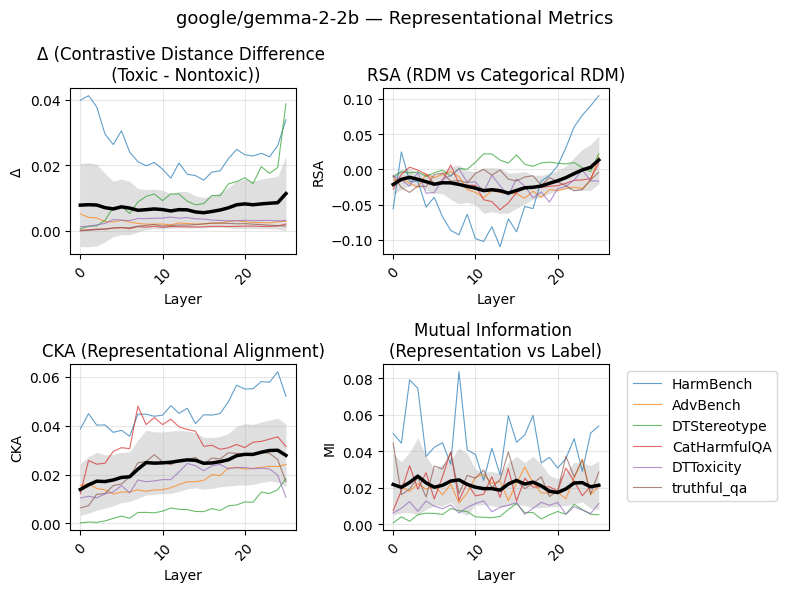


=== Processing model: meta-llama/Llama-3.2-3B ===


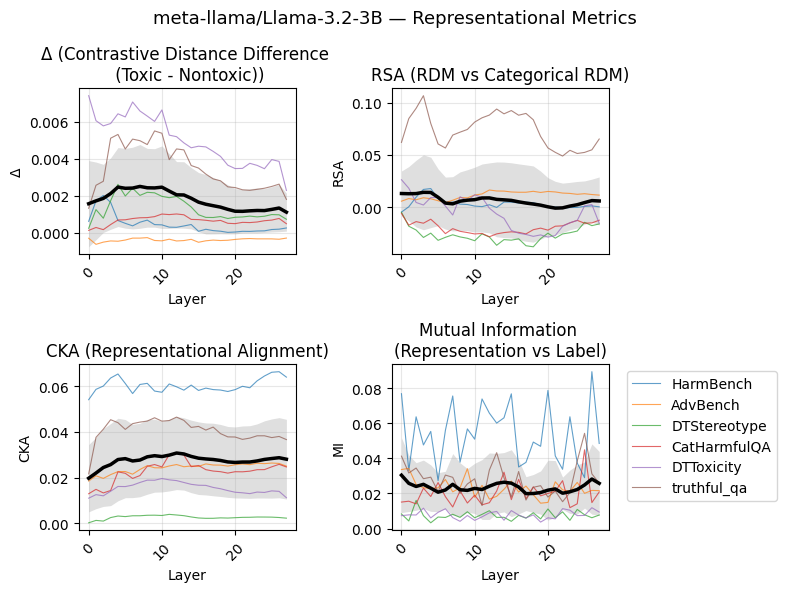


=== Processing model: Qwen/Qwen2.5-3B ===


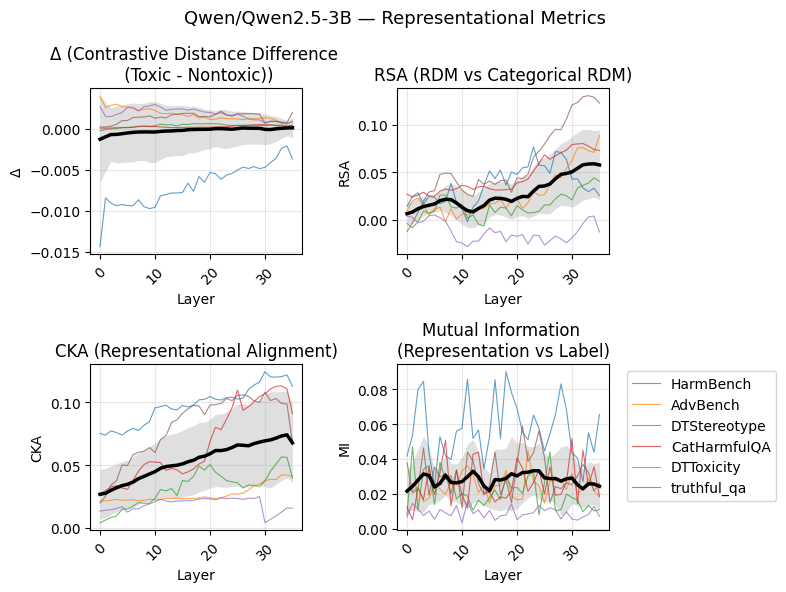


=== Processing model: allenai/OLMo-2-0425-1B ===


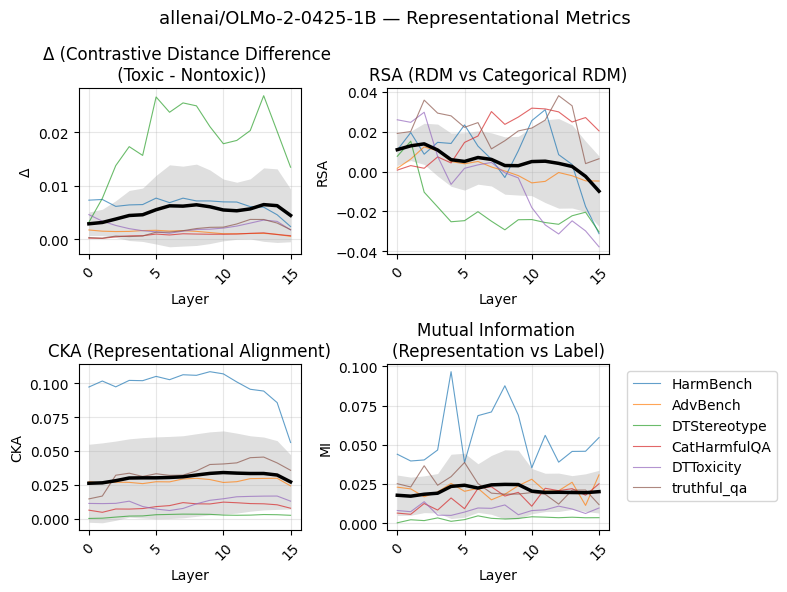


=== Processing model: allenai/OLMo-2-0425-1B-Instruct ===


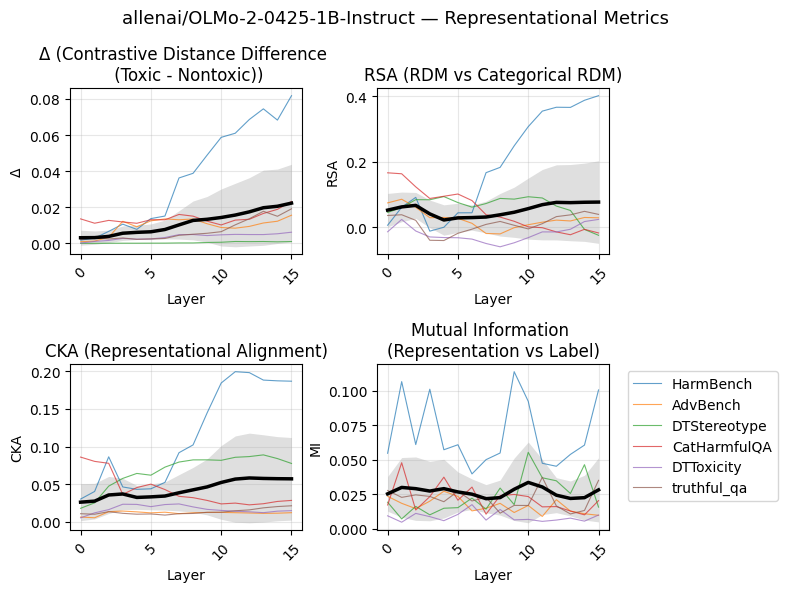

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mutual_info_score
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform

# --- Optional: CKA helper ---
def compute_cka(X, Y):
    """Centered Kernel Alignment between two representation matrices."""
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    Kx = X @ X.T
    Ky = Y @ Y.T
    hsic = np.sum(Kx * Ky)
    norm = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    return hsic / norm


# --- Helper for RSA (C) ---
def upper_triangle(mat):
    return mat[np.triu_indices_from(mat, k=1)]


def rsa_rdm(model_rdm, true_rdm):
    """RSA correlation (Spearman) between model and true categorical RDMs."""
    m = upper_triangle(model_rdm)
    t = upper_triangle(true_rdm)
    corr, _ = spearmanr(m, t)
    return corr

models = [ "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]
# --- Start analysis ---
for model in models:
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_1, v1 = load_harmbench(model, output_dir)
    layers = sorted(list(X_1.keys()), key=lambda x: int(x.split('.')[-1]))

    print(f"\n=== Processing model: {model} ===")
    results = {} #{'Δ': [], 'RSA': [], 'CKA': [], 'MI': []}

    for layer in layers:
        X = X_1[layer].float().numpy()
        y = (v1 > 0).astype(int)
        results[layer] = {}

        # --- B. Contrastive Δ (mean distance difference) ---
        cos = cosine_similarity(X)
        dist_to_class_mean = []
        for c in [0, 1]:
            cls_vecs = X[y == c].mean(0, keepdims=True)
            dists = 1 - cosine_similarity(X, cls_vecs).squeeze()
            dist_to_class_mean.append(dists)
        Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
        results[layer]['Δ'] = [Δ]

        # --- C. RSA (model RDM vs. true categorical RDM) ---
        model_rdm = 1 - cosine_similarity(X)
        true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
        rsa_val = rsa_rdm(model_rdm, true_rdm)
        results[layer]['RSA'] = [rsa_val]

        # --- D. CKA (representational alignment with categorical kernel) ---
        y_vec = y.reshape(-1, 1)
        cat_kernel = y_vec @ y_vec.T  # binary kernel
        cka_val = compute_cka(X, cat_kernel)
        results[layer]['CKA'] = [cka_val]

        # --- E. Mutual Information (representation vs. label) ---
        # Flatten activations along feature axis for MI
        proj = X @ np.random.randn(X.shape[1], 1)  # random projection for stability
        proj_disc = np.digitize(proj.squeeze(), np.histogram(proj, bins=20)[1])
        mi_val = mutual_info_score(proj_disc, y)
        results[layer]['MI'] = [mi_val]

        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)
            X = X_2[layer].float().numpy()
            y = v2

            # --- B. Contrastive Δ (mean distance difference) ---
            cos = cosine_similarity(X)
            dist_to_class_mean = []
            for c in [0, 1]:
                cls_vecs = X[y == c].mean(0, keepdims=True)
                dists = 1 - cosine_similarity(X, cls_vecs).squeeze()
                dist_to_class_mean.append(dists)
            Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
            results[layer]['Δ'].append(Δ)

            # --- C. RSA (model RDM vs. true categorical RDM) ---
            model_rdm = 1 - cosine_similarity(X)
            true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
            rsa_val = rsa_rdm(model_rdm, true_rdm)
            results[layer]['RSA'].append(rsa_val)

            # --- D. CKA (representational alignment with categorical kernel) ---
            y_vec = y.reshape(-1, 1)
            cat_kernel = y_vec @ y_vec.T  # binary kernel
            cka_val = compute_cka(X, cat_kernel)
            results[layer]['CKA'].append(cka_val)

            # --- E. Mutual Information (representation vs. label) ---
            # Flatten activations along feature axis for MI
            proj = X @ np.random.randn(X.shape[1], 1)  # random projection for stability
            proj_disc = np.digitize(proj.squeeze(), np.histogram(proj, bins=20)[1])
            mi_val = mutual_info_score(proj_disc, y)
            results[layer]['MI'].append(mi_val)

    # --- Plotting ---
    fig, axs = plt.subplots(2, 2, figsize=(8, 6))
    metrics = ['Δ', 'RSA', 'CKA', 'MI']
    titles = [
        'Δ (Contrastive Distance Difference \n (Toxic - Nontoxic))',
        'RSA (RDM vs Categorical RDM)',
        'CKA (Representational Alignment)',
        'Mutual Information \n(Representation vs Label)'
    ]
    datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    
        
    for i, metric in enumerate(metrics):
        ax = axs.flat[i]
        plt.sca(ax)

        plot_metric_ribbon(results, layers, metric=metric, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
        # for d, data in enumerate(['y/Harmbench'] + datasets_list):
        #     data_vals = [results[layer][metric][d] for layer in layers]

        #     ax.plot([int(l.split('.')[-1]) for l in layers], data_vals, marker='.', label=data.split('/')[-1])
        # ax.plot(layers, results[metric], marker='o', linewidth=2)
        ax.set_title(titles[i])
        ax.set_xlabel("Layer")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

    plt.legend(datasets, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f"{model} — Representational Metrics", fontsize=13)
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_all_metrics.png",
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


In [ ]:

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

def pca_drift_scatter(Xb, Xi, layer_name, n_comp=2, subsample=2000, seed=0):
    rng = np.random.default_rng(seed)
    n = Xb.shape[0]
    idx = rng.choice(n, size=min(subsample, n), replace=False)
    Xb, Xi = Xb[idx], Xi[idx]

    # shared PCA on concatenated data
    Xb_c = Xb - Xb.mean(0, keepdims=True)
    Xi_c = Xi - Xi.mean(0, keepdims=True)
    Xcat = np.vstack([Xb_c, Xi_c])
    pca = PCA(n_components=n_comp, svd_solver='full').fit(Xcat)

    XY = pca.transform(Xcat)
    nb = Xb.shape[0]
    XYb, XYi = XY[:nb], XY[nb:]

    evr = pca.explained_variance_ratio_.sum()

    plt.figure(figsize=(5,4))
    plt.scatter(XYb[:,0], XYb[:,1], s=6, alpha=.35, label='base')
    plt.scatter(XYi[:,0], XYi[:,1], s=6, alpha=.35, label='instruct')
    plt.title(f'Layer {layer_name} — shared PCA (EVR={evr:.2f})')
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend()
    plt.tight_layout(); plt.show()


def center(K):  # double-centering
    n = K.shape[0]
    H = np.eye(n) - np.ones((n,n))/n
    return H @ K @ H

def linear_cka(X, Y):
    # X,Y: (n, d), mean-centered across samples
    Xc = X - X.mean(0, keepdims=True)
    Yc = Y - Y.mean(0, keepdims=True)
    Kx = Xc @ Xc.T
    Ky = Yc @ Yc.T
    Kxc, Kyc = center(Kx), center(Ky)
    num = (Kxc * Kyc).sum()
    den = np.sqrt((Kxc * Kxc).sum() * (Kyc * Kyc).sum()) + 1e-12
    return float(num/den)

def principal_angles_deg(XA, XB, k=50):
    # mean-center
    A = XA - XA.mean(0, keepdims=True)
    B = XB - XB.mean(0, keepdims=True)
    # top-k right singular vectors (feature subspace)
    Ua, Sa, Vta = svd(A, full_matrices=False)
    Ub, Sb, Vtb = svd(B, full_matrices=False)
    Va = Vta[:k].T   # (d, k)
    Vb = Vtb[:k].T   # (d, k)
    # cosines of principal angles are singular values of Va^T Vb
    s = np.linalg.svd(Va.T @ Vb, compute_uv=False)
    s = np.clip(s, -1, 1)
    ang = np.degrees(np.arccos(s))
    return ang  # length k (sorted desc cosines → asc angles)

from scipy.linalg import orthogonal_procrustes

def procrustes_mse(XA, XB):
    A = XA - XA.mean(0, keepdims=True)
    B = XB - XB.mean(0, keepdims=True)
    # optional: whiten on A’s train split if you want scale-invariance;
    # here we use pure orthogonal alignment (rotation+reflection+scale).
    R, scale = orthogonal_procrustes(B, A)   # B@R ≈ A
    B_hat = B @ R
    return float(np.mean((A - B_hat)**2))
def principal_angles_deg_safe(XA, XB, k=50):
    A = XA - XA.mean(0, keepdims=True)
    B = XB - XB.mean(0, keepdims=True)
    Ua, Sa, Vta = svd(A, full_matrices=False)
    Ub, Sb, Vtb = svd(B, full_matrices=False)
    k_eff = min(k, Vta.shape[0], Vtb.shape[0])  # cap to available components
    Va = Vta[:k_eff].T
    Vb = Vtb[:k_eff].T
    s = np.linalg.svd(Va.T @ Vb, compute_uv=False)
    s = np.clip(s, -1, 1)
    return np.degrees(np.arccos(s))  # len = k_eff

import numpy as np, matplotlib.pyplot as plt

def rsm(X):
    Xc = X - X.mean(0, keepdims=True)
    Xn = Xc / (np.linalg.norm(Xc, axis=1, keepdims=True) + 1e-12)
    return Xn @ Xn.T  # cosine RSM

def plot_rsm_block(Xb, Xi, yb, yi, layer_name):
    orderb = np.argsort(yb)  # 0s then 1s
    orderi = np.argsort(yi)
    Rb = rsm(Xb)[orderb][:, orderb]
    Ri = rsm(Xi)[orderi][:, orderi]
    fig, axs = plt.subplots(1, 2, figsize=(8, 3.2))
    im0 = axs[0].imshow(Rb, vmin=-1, vmax=1, cmap='coolwarm')
    axs[0].set_title(f'Base RSM (sorted) — {layer_name}')
    im1 = axs[1].imshow(Ri, vmin=-1, vmax=1, cmap='coolwarm')
    axs[1].set_title(f'Instruct RSM (sorted) — {layer_name}')
    for ax in axs: 
        ax.set_xticks([])
        ax.set_yticks([])
    fig.colorbar(im1, ax=axs, shrink=0.8); plt.tight_layout(); plt.show()

def intra_inter_cos(X, y):
    C = rsm(X)  # cosine similarity
    S = C[y==0][:, y==0].copy()
    H = C[y==1][:, y==1].copy()
    B = C[y==0][:, y==1].copy()
    # drop diagonals and reflect duplicates approximately by sampling upper triangles
    def upper_no_diag(M):
        m = M.shape[0]
        iu = np.triu_indices(m, k=1)
        return M[iu]
    intra0 = upper_no_diag(S)
    intra1 = upper_no_diag(H)
    inter  = B.ravel()
    return intra0, intra1, inter

def plot_intra_inter(Xb, Xi, yb, yi, layer_name, bins=40):
    b0,b1,bi = intra_inter_cos(Xb, yb)
    i0,i1,ii = intra_inter_cos(Xi, yi)
    fig,axs = plt.subplots(1,2, figsize=(9,3))
    for ax, (a0,a1,ab), title in [(axs[0], (b0,b1,bi), 'Base'),
                                  (axs[1], (i0,i1,ii), 'Instruct')]:
        ax.hist(ab, bins=bins, alpha=.35, label='between (0 vs 1)')
        ax.hist(a0, bins=bins, alpha=.35, label='within 0')
        ax.hist(a1, bins=bins, alpha=.35, label='within 1')
        ax.set_title(f'{title} — {layer_name}'); ax.set_xlabel('Cosine similarity'); ax.legend()
    plt.tight_layout()
    plt.show()

from sklearn.metrics import roc_auc_score

def safety_axis_auc(X, y):
    # difference-of-means direction (like LDA without covariance)
    mu0 = X[y==0].mean(0); mu1 = X[y==1].mean(0)
    w = mu1 - mu0
    w = w / (np.linalg.norm(w) + 1e-12)
    scores = (X - X.mean(0)).dot(w)
    auc = roc_auc_score(y, scores)
    return scores, auc

def plot_safety_projection(Xb, Xi, yb, yi, layer_name):
    sb, auc_b = safety_axis_auc(Xb, yb)
    si, auc_i = safety_axis_auc(Xi, yi)
    fig, ax = plt.subplots(1,1, figsize=(6,3))
    ax.hist(sb[yb==0], bins=40, alpha=.4, label=f'Base safe (AUC={auc_b:.2f})')
    ax.hist(sb[yb==1], bins=40, alpha=.4, label='Base unsafe')
    ax.hist(si[yi==0], bins=40, alpha=.4, label=f'Instr safe (AUC={auc_i:.2f})')
    ax.hist(si[yi==1], bins=40, alpha=.4, label='Instr unsafe')
    ax.set_title(f'Projection on safety axis — {layer_name}')
    ax.set_xlabel('score')
    ax.legend()
    plt.tight_layout()
    plt.show()

from sklearn.metrics import silhouette_score

def fisher_ratio(X, y):
    Xc = X - X.mean(0, keepdims=True)
    mu0, mu1 = Xc[y==0].mean(0), Xc[y==1].mean(0)
    s0  = Xc[y==0].var(0).mean()
    s1  = Xc[y==1].var(0).mean()
    between = np.sum((mu1 - mu0)**2)
    within  = s0 + s1 + 1e-12
    return float(between / within)

def silhouette(X, y):
    # cosine distance silhouette
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    return float(silhouette_score(Xn, y, metric='cosine'))


models = [( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
          ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]



for pair in models:
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))
    yb = (v1b > 0).astype(int)
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    yi = (v1i > 0).astype(int)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))


    res_i = []
    res_b = []
    min_angle = []
    mean_angle = []
    cka_mat = np.zeros((len(layer_names), len(layer_names)))
    cos_ball = []
    cos_iall = []
    for i, layer in enumerate(layer_names[5::5]):
    
        # plot_safety_projection(X_1b[layer].float().numpy(), X_1i[layer].float().numpy(), yb, yi, layer)
        # plot_intra_inter(X_1b[layer].float().numpy(), X_1i[layer].float().numpy(), yb, yi, layer)
        # plot_rsm_block(X_1b[layer].float().numpy(), X_1i[layer].float().numpy(), yb, yi, layer)

    # per layer curves
    f_base = [fisher_ratio(X_1b[L].float().numpy(), yb) for L in layer_names]
    f_inst = [fisher_ratio(X_1i[L].float().numpy(), yi) for L in layer_names]
    s_base = [silhouette(X_1b[L].float().numpy(), yb)   for L in layer_names]
    s_inst = [silhouette(X_1i[L].float().numpy(), yi)   for L in layer_names]

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.plot(f_base, label='Base model')
    plt.plot(f_inst,  label='Instruct model')
    plt.xlabel('Layer')
    plt.ylabel('Fisher Ratio (↑ better)')
    plt.subplot(1,2,2)
    plt.plot(s_base, label='Base model')
    plt.plot(s_inst,  label='Instruct model')
    plt.xlabel('Layer')
    plt.ylabel('Silhouette Score (↑ better)')
    plt.legend()
    plt.suptitle(f'Class Separability Metrics: {model_base} vs {model_it}')
    plt.tight_layout()
    plt.show()
        # plt.plot(...): instruct >> base in later layers if it separates classes

        # for j, layer2 in enumerate(layer_names):
        #     cka_mat[i, j] = linear_cka(X_1b[layer].float().numpy(), X_1i[layer2].float().numpy())
        # cosine_base = cosine_similarity(X_1b[layer].float().numpy())
        # cosine_it = cosine_similarity(X_1i[layer].float().numpy())
        # cos_b = cosine_base[v1b==1][:, v1b==0]
        # cos_i = cosine_it[v1i==1][:, v1i==0]
        # cos_b_mean = cos_b.mean()
        # cos_i_mean = cos_i.mean()
        # res_i.append(cos_i_mean)
        # res_b.append(cos_b_mean)
        # ang = principal_angles_deg_safe(X_1b[layer].float().numpy(), X_1i[layer].float().numpy(), k=50)
        # min_angle.append(ang[-1])         # smallest angle (closest directions)
        # mean_angle.append(ang.mean())
        # cos_ball.append(cos_b.flatten())
        # cos_iall.append(cos_i.flatten())


    # plt.figure(figsize=(10,10))
    # plt.subplot(2,2,1)
    # plt.plot(mean_angle, marker='.', label='mean principal angle')
    # plt.plot(min_angle,  marker='.', label='smallest principal angle')
    # plt.xlabel('Layer')
    # plt.ylabel('Angle (deg)')
    # plt.legend()
    # plt.subplot(2,2,2)
    # proc_err = [procrustes_mse(X_1b[layer].float().numpy(), X_1i[layer].float().numpy()) for layer in layer_names]
    # plt.plot(proc_err, marker='o')
    # plt.xlabel('Layer'); plt.ylabel('Procrustes MSE (↓ better)')
    # plt.subplot(2,2,3)
    # plt.plot(res_b, marker='o', label='Base model')
    # plt.plot(res_i, marker='o', label='Instruct model')
    # plt.xlabel('Layer'); plt.ylabel('Mean cosine similarity \n (toxic vs nontoxic)')
    # plt.legend()
    # plt.subplot(2,2,4)
    # layers = np.arange(len(cos_ball))  # make sure it's a NumPy array
    # print(layers.shape)
    # plt.boxplot(cos_ball, positions=layers-0.2, widths=0.35, patch_artist=True,
    #         boxprops=dict(facecolor='cornflowerblue', alpha=0.5),
    #         medianprops=dict(color='black'), showfliers=False)
    # plt.boxplot(cos_iall, positions=layers+0.2, widths=0.35, patch_artist=True,
    #             boxprops=dict(facecolor='orange', alpha=0.5),
    #             medianprops=dict(color='black'), showfliers=False)
    # plt.xlabel('Layer')
    # plt.ylabel('Cosine similarity \n (toxic vs nontoxic)')
    # plt.tight_layout()
    # plt.show()

        # example: early and late layers
        # pca_drift_scatter(X_1b[layer].float().numpy(),  X_1i[layer].float().numpy(),  layer)


        

    # # Plot as heatmap (seaborn or matplotlib)
    # plt.subplot(1,2,1)
    # sns.heatmap(cka_mat, vmin=0, vmax=1, cmap='magma'); plt.xlabel('Instruct layer'); plt.ylabel('Base layer')
    # plt.title(f'CKA Similarity: {model_base} vs {model_it}')
    # plt.subplot(1,2,2)
    # same_layer_cka = np.diag(cka_mat)
    # plt.plot(same_layer_cka, marker='o')
    # plt.xlabel('Layer')
    # plt.ylabel('CKA(Base vs Instruct)')

    # plt.show()

    # plt.close()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-12
models = [ "google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]

def _svd_vals_centered(X):
    Xc = X - X.mean(0, keepdims=True)
    # If degenerate, return empty
    if Xc.shape[0] < 2 or Xc.shape[1] < 2:
        return np.array([])
    # economical SVD
    s = np.linalg.svd(Xc, full_matrices=False, compute_uv=False)
    # keep positive, numeric
    s = np.asarray(s, dtype=np.float64)
    s = np.clip(s, 0, None)
    return s

def _spectrum_metrics_from_svals(s, top_m=50):
    """
    s: singular values (1D, descending). We work with lam = s^2 (variance power).
    Returns dict of complexity/smoothness metrics.
    """
    if s.size == 0:
        return dict(alpha=np.nan, entropy=np.nan, eff_rank=np.nan,
                    pr=np.nan, flatness=np.nan, k80=np.nan)

    lam = s**2
    lam = lam[lam > 0]  # drop exact zeros if any
    if lam.size == 0:
        return dict(alpha=np.nan, entropy=np.nan, eff_rank=np.nan,
                    pr=np.nan, flatness=np.nan, k80=np.nan)

    # normalize for probabilities
    Lsum = lam.sum()
    p = lam / (Lsum + EPS)

    # --- Spectral slope alpha via log-log fit (power law) ---
    m = min(top_m, lam.size)
    x = np.arange(1, m + 1, dtype=np.float64)
    y = lam[:m]
    # robust-ish protection against zeros
    alpha = np.nan
    if np.all(y > 0):
        coeff = np.polyfit(np.log(x), np.log(y), 1)  # log y = a*log x + b
        alpha = -coeff[0]  # y ~ x^{-alpha}

    # --- Spectral entropy & effective rank ---
    H = -np.sum(p * np.log(p + EPS))                # natural log
    eff_rank = np.exp(H)

    # --- Participation ratio (PR) ---
    pr = (Lsum**2) / (np.sum(lam**2) + EPS)

    # --- Spectral flatness (geom/arith mean) ---
    gm = np.exp(np.mean(np.log(lam + EPS)))
    am = np.mean(lam)
    flatness = gm / (am + EPS)

    # --- k to reach 80% variance ---
    c = np.cumsum(p)
    k80 = 1 + np.searchsorted(c, 0.80)  # 1-indexed count

    return dict(alpha=float(alpha), entropy=float(H), eff_rank=float(eff_rank),
                pr=float(pr), flatness=float(flatness), k80=float(k80))

def compute_complexity_curves_per_layer(X_dict, y_binary, top_m=50):
    """
    X_dict: dict[layer_name] -> (n x d) activations (numpy or torch)
    y_binary: (n,) {0,1}
    Returns: layer_ids, metrics_harm, metrics_safe (each is dict of metric->list over layers)
    """
    # ensure numpy
    def to_np(A):
        return A.detach().cpu().float().numpy() if hasattr(A, "detach") else np.asarray(A, dtype=np.float64)

    layers_sorted = sorted(list(X_dict.keys()), key=lambda x: int(str(x).split('.')[-1]))
    layer_ids = [int(str(l).split('.')[-1]) for l in layers_sorted]

    metrics_h = {k: [] for k in ["alpha","entropy","eff_rank","pr","flatness","k80"]}
    metrics_s = {k: [] for k in ["alpha","entropy","eff_rank","pr","flatness","k80"]}

    for layer in layers_sorted:
        X = to_np(X_dict[layer])
        th = (y_binary == 1)
        ts = (y_binary == 0)

        # guard: need at least 2 samples to compute SVD
        s_h = _svd_vals_centered(X[th]) if th.sum() >= 2 else np.array([])
        s_s = _svd_vals_centered(X[ts]) if ts.sum() >= 2 else np.array([])

        mh = _spectrum_metrics_from_svals(s_h, top_m=top_m)
        ms = _spectrum_metrics_from_svals(s_s, top_m=top_m)

        for k in metrics_h.keys():
            metrics_h[k].append(mh[k])
            metrics_s[k].append(ms[k])

    return layer_ids, metrics_h, metrics_s

def plot_complexity_curves(model_name, layer_ids, metrics_h, metrics_s):
    """
    Plot 6 metrics across layers: alpha, entropy, eff_rank, PR, flatness, k80
    """
    titles = {
        "alpha": "Spectral slope α (larger = smoother / lower-rank)",
        "entropy": "Spectral entropy H",
        "eff_rank": "Effective rank (exp(H))",
        "pr": "Participation ratio",
        "flatness": "Spectral flatness (geom/arith)",
        "k80": "k @ 80% explained variance"
    }
    keys = ["alpha","entropy","eff_rank","pr","flatness","k80"]

    fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
    axes = axes.ravel()
    for i, k in enumerate(keys):
        ax = axes[i]
        ax.plot(layer_ids, metrics_h[k], '-o', label="Harmful", color='tab:red', alpha=0.9)
        ax.plot(layer_ids, metrics_s[k], '-o', label="Safe",    color='tab:green', alpha=0.9)
        ax.set_title(titles[k], fontsize=10)
        ax.grid(alpha=0.3)
        if i >= 3:
            ax.set_xlabel("Layer")
        # y-labels on left column for readability
        if i % 3 == 0:
            ax.set_ylabel("Value")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center", ncol=2, frameon=False)
    fig.suptitle(f"{model_name}: Spectral complexity / smoothness across layers", y=1.02)
    fig.tight_layout()
    plt.show()

# =========================
# Use it in your loop
# =========================
for model in models:
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_1, v1 = load_harmbench(model, output_dir)          # your loader
    y = (np.asarray(v1) > 0).astype(int)                 # 1 = harmful, 0 = safe

    layer_ids, metrics_h, metrics_s = compute_complexity_curves_per_layer(
        X_1, y, top_m=50
    )
    plot_complexity_curves(safe_model_name, layer_ids, metrics_h, metrics_s)


In [ ]:
# ============================ ALL-IN-ONE CODE ============================
import os, re
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity

# -------------------- core helpers --------------------
def zmean(X):
    """Zero-mean across samples (rows)."""
    return X - X.mean(0, keepdims=True)

def rsm_cosine(X):
    """Cosine Representational Similarity Matrix."""
    Xc = zmean(X)
    Xn = Xc / (np.linalg.norm(Xc, axis=1, keepdims=True) + 1e-12)
    return Xn @ Xn.T

def center(K):
    """Double-centering for CKA."""
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def linear_cka(X, Y):
    """Linear CKA similarity in [0,1]. Label-free."""
    Xc, Yc = zmean(X), zmean(Y)
    Kx, Ky = Xc @ Xc.T, Yc @ Yc.T
    Kxc, Kyc = center(Kx), center(Ky)
    num = (Kxc * Kyc).sum()
    den = np.sqrt((Kxc*Kxc).sum() * (Kyc*Kyc).sum()) + 1e-12
    return float(num / den)

def principal_angles_deg_safe(XA, XB, k=50):
    """Principal angles (deg) between top-k feature subspaces; safe for rank limits."""
    A, B = zmean(XA), zmean(XB)
    Ua, Sa, Vta = svd(A, full_matrices=False)
    Ub, Sb, Vtb = svd(B, full_matrices=False)
    k_eff = int(min(k, Vta.shape[0], Vtb.shape[0]))
    Va, Vb = Vta[:k_eff].T, Vtb[:k_eff].T  # (d,k)
    s = np.linalg.svd(Va.T @ Vb, compute_uv=False)
    s = np.clip(s, -1, 1)
    return np.degrees(np.arccos(s))  # len=k_eff (sorted by singular values desc)

def procrustes_mse(XA, XB):
    """MSE after best orthogonal alignment of XB to XA (label-free). Lower is better."""
    A, B = zmean(XA), zmean(XB)
    R, _ = orthogonal_procrustes(B, A)  # B @ R ≈ A
    return float(np.mean((A - B @ R) ** 2))

def fisher_ratio(X, y):
    """Between-class / within-class variance ratio (↑ better separation)."""
    if len(np.unique(y)) < 2: return np.nan
    Xc = zmean(X)
    X0, X1 = Xc[y==0], Xc[y==1]
    if len(X0)==0 or len(X1)==0: return np.nan
    mu0, mu1 = X0.mean(0), X1.mean(0)
    within = X0.var(0).mean() + X1.var(0).mean() + 1e-12
    between = np.sum((mu1 - mu0) ** 2)
    return float(between / within)

def silhouette_cosine(X, y):
    """Cosine-distance silhouette (↑ better)."""
    if len(np.unique(y)) < 2: return np.nan
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    return float(silhouette_score(Xn, y, metric='cosine'))

def safety_axis_scores_auc(X, y):
    """Project on difference-of-means axis; return scores and AUC."""
    if len(np.unique(y)) < 2: return np.zeros(len(X)), np.nan
    Xc = zmean(X)
    X0, X1 = Xc[y==0], Xc[y==1]
    if len(X0)==0 or len(X1)==0: return np.zeros(len(X)), np.nan
    w = X1.mean(0) - X0.mean(0)
    w = w / (np.linalg.norm(w) + 1e-12)
    s = Xc @ w
    return s, float(roc_auc_score(y, s))

def shared_pca_2d(Xb, Xi, subsample=2000, seed=0):
    """Shared 2D PCA on concatenated, zero-meaned data; returns 2D coords and EVR."""
    rng = np.random.default_rng(seed)
    n = min(Xb.shape[0], Xi.shape[0])
    idx = rng.choice(n, size=min(subsample, n), replace=False)
    Xb_, Xi_ = Xb[idx], Xi[idx]
    Xcat = np.vstack([zmean(Xb_), zmean(Xi_)])
    pca = PCA(n_components=2, svd_solver='full').fit(Xcat)
    XY = pca.transform(Xcat)
    nb = len(idx)
    return XY[:nb], XY[nb:], float(pca.explained_variance_ratio_.sum())
def subspace_overlap_global(X, y, k=20, m=None, n_boot=20, seed=0):
    """
    Robust safe/unsafe subspace overlap ∈ [0,1] within one model.
    Global SVD basis on all samples; then compare class top-k subspaces inside that basis.
    Bootstraps the smaller class to stabilize when counts are tiny.
    """
    import numpy as np
    from numpy.linalg import svd

    X = np.asarray(X)
    Xc = X - X.mean(0, keepdims=True)
    U, S, Vt = svd(Xc, full_matrices=False)
    r = Vt.shape[0]
    if m is None: m = r
    m = int(min(m, r))
    V_m = Vt[:m].T  # (d, m)

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    X0 = X[idx0]; X1 = X[idx1]

    # Project to shared m-dim basis
    Z0 = (X0 - X.mean(0, keepdims=True)) @ V_m if len(X0) else np.zeros((0, m))
    Z1 = (X1 - X.mean(0, keepdims=True)) @ V_m if len(X1) else np.zeros((0, m))

    rng = np.random.default_rng(seed)

    def _basis(Z):
        if len(Z) <= 1:
            # degenerate: return a dummy 1D basis
            return np.zeros((m, 1)), 1
        Zc = Z - Z.mean(0, keepdims=True)
        _, _, VtZ = svd(Zc, full_matrices=False)
        kk = min(k, VtZ.shape[0])
        return VtZ[:kk].T, kk  # (m, kk), kk

    overlaps = []
    reps = max(1, n_boot)
    for _ in range(reps):
        A, B = Z0, Z1
        if len(Z0) and len(Z1) and n_boot > 0:
            n_big = max(len(Z0), len(Z1))
            if len(Z0) < n_big:
                A = Z0[rng.choice(len(Z0), size=n_big, replace=True)]
            if len(Z1) < n_big:
                B = Z1[rng.choice(len(Z1), size=n_big, replace=True)]
        Ea, ka = _basis(A)
        Eb, kb = _basis(B)
        kk = min(ka, kb)
        if kk == 0:
            overlaps.append(np.nan)
            continue
        # singular values of the basis overlap matrix
        s = np.linalg.svd(Ea.T @ Eb, compute_uv=False)  # 1D vector
        # mean cos^2 of principal angles
        overlaps.append(float(np.sum(s**2) / kk))

    # average (ignore NaNs if any)
    overlaps = np.array(overlaps, dtype=float)
    if np.all(np.isnan(overlaps)):
        return float('nan')
    return float(np.nanmean(overlaps))


def intra_inter_cos_distributions(X, y):
    """Return arrays for within-safe, within-unsafe, and between-class cosine similarities."""
    C = rsm_cosine(X)
    idx0, idx1 = np.where(y == 0)[0], np.where(y == 1)[0]

    def upper_no_diag(M):
        if M.shape[0] < 2: return np.array([])
        iu = np.triu_indices(M.shape[0], k=1)
        return M[iu]

    within0 = upper_no_diag(C[np.ix_(idx0, idx0)]) if len(idx0) else np.array([])
    within1 = upper_no_diag(C[np.ix_(idx1, idx1)]) if len(idx1) else np.array([])
    between = C[np.ix_(idx0, idx1)].ravel() if (len(idx0) and len(idx1)) else np.array([])
    return within0, within1, between

# -------------------- plotting dashboards --------------------
def plot_layer_dashboard(Xb, Xi, yb, yi, layer_name, show_rsm=True, bins=40):
    """Single-layer, multi-view figure: safety 1D, cosine distributions, RSMs.
       Uses yb for base and yi for instruct (they may differ!)."""
    # 1D safety projections
    sb, auc_b = safety_axis_scores_auc(Xb, yb)
    si, auc_i = safety_axis_scores_auc(Xi, yi)

    fig = plt.figure(figsize=(11, 8))

    # (1) Safety axis histograms
    ax1 = plt.subplot2grid((2, 2), (0, 0))
    if sb.size:
        ax1.hist(sb[yb == 0], bins=bins, alpha=.5, label=f'Base safe (AUC={auc_b:.2f})')
        ax1.hist(sb[yb == 1], bins=bins, alpha=.5, label='Base unsafe')
    if si.size:
        ax1.hist(si[yi == 0], bins=bins, alpha=.5, label=f'Instr safe (AUC={auc_i:.2f})')
        ax1.hist(si[yi == 1], bins=bins, alpha=.5, label='Instr unsafe')
    ax1.set_title(f'Projection on safety axis — {layer_name}')
    ax1.set_xlabel('score'); ax1.legend()

    # (2) Intra/inter cosine distributions
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    b0, b1, bi = intra_inter_cos_distributions(Xb, yb)
    i0, i1, ii = intra_inter_cos_distributions(Xi, yi)
    for arr, label in [(bi, 'between (0 vs 1)'), (b0, 'within 0'), (b1, 'within 1')]:
        if arr.size: ax2.hist(arr, bins=bins, alpha=.35, label=f'Base {label}')
    for arr, label in [(ii, 'between (0 vs 1)'), (i0, 'within 0'), (i1, 'within 1')]:
        if arr.size: ax2.hist(arr, bins=bins, alpha=.35, label=f'Instr {label}')
    ax2.set_title(f'Cosine similarity — {layer_name}')
    ax2.set_xlabel('cosine'); ax2.legend(fontsize=8)

    # (3) RSMs (sorted by each model's own labels)
    if show_rsm:
        ax3 = plt.subplot2grid((2, 2), (1, 0))
        ord_b = np.argsort(yb)
        Rb = rsm_cosine(Xb)[ord_b][:, ord_b]
        im0 = ax3.imshow(Rb, vmin=-1, vmax=1, cmap='coolwarm')
        ax3.set_title(f'Base RSM (sorted by yb) — {layer_name}')
        ax3.set_xticks([]); ax3.set_yticks([])

        ax4 = plt.subplot2grid((2, 2), (1, 1))
        ord_i = np.argsort(yi)
        Ri = rsm_cosine(Xi)[ord_i][:, ord_i]
        im1 = ax4.imshow(Ri, vmin=-1, vmax=1, cmap='coolwarm')
        ax4.set_title(f'Instruct RSM (sorted by yi) — {layer_name}')
        ax4.set_xticks([]); ax4.set_yticks([])

        cbar = fig.colorbar(im1, ax=[ax3, ax4], shrink=0.8)
        cbar.ax.set_ylabel('cosine', rotation=90)

    plt.tight_layout(); plt.show()

def plot_pair_curves(X_base, X_inst, yb, yi, layers, k_pa=50, k_overlap=20):
    """Across-layer curves: principal angles, Procrustes, Fisher, silhouette, subspace overlap.
       Uses model-specific labels for class metrics."""
    mean_pa, min_pa, proc = [], [], []
    fish_b, fish_i, sil_b, sil_i = [], [], [], []
    overlap_b, overlap_i = [], []

    for L in layers:
        Xb, Xi = X_base[L].float().numpy(), X_inst[L].float().numpy()

        # label-free geometry changes
        ang = principal_angles_deg_safe(Xb, Xi, k=k_pa)
        mean_pa.append(ang.mean())
        min_pa.append(ang[-1])
        proc.append(procrustes_mse(Xb, Xi))

        # per-model class separability (use each model's labels)
        fish_b.append(fisher_ratio(Xb, yb))
        fish_i.append(fisher_ratio(Xi, yi))
        sil_b.append(silhouette_cosine(Xb, yb))
        sil_i.append(silhouette_cosine(Xi, yi))

        # safe/unsafe subspace overlap within each model (robust global basis)
        overlap_b.append(subspace_overlap_global(Xb, yb, k=k_overlap, m=None, n_boot=20))
        overlap_i.append(subspace_overlap_global(Xi, yi, k=k_overlap, m=None, n_boot=20))

    x = np.arange(len(layers))
    fig, axs = plt.subplots(3, 2, figsize=(12, 10))

    # principal angles
    axs[0, 0].plot(x, mean_pa, marker='o', label='mean principal angle')
    axs[0, 0].plot(x, min_pa, marker='o', label='smallest principal angle')
    axs[0, 0].set_xlabel('Layer'); axs[0, 0].set_ylabel('Angle (deg)'); axs[0, 0].legend()

    # procrustes
    axs[0, 1].plot(x, proc, marker='o')
    axs[0, 1].set_xlabel('Layer'); axs[0, 1].set_ylabel('Procrustes MSE (↓)')

    # Fisher ratio
    axs[1, 0].plot(x, fish_b, marker='o', label='Base')
    axs[1, 0].plot(x, fish_i, marker='o', label='Instruct')
    axs[1, 0].set_xlabel('Layer'); axs[1, 0].set_ylabel('Fisher ratio (↑)'); axs[1, 0].legend()

    # Silhouette
    axs[1, 1].plot(x, sil_b, marker='o', label='Base')
    axs[1, 1].plot(x, sil_i, marker='o', label='Instruct')
    axs[1, 1].set_xlabel('Layer'); axs[1, 1].set_ylabel('Silhouette (↑)'); axs[1, 1].legend()

    # Subspace overlap (safe vs unsafe, 0..1; lower means more separation)
    axs[2, 0].plot(x, overlap_b, marker='o', label='Base')
    axs[2, 0].plot(x, overlap_i, marker='o', label='Instruct')
    axs[2, 0].set_xlabel('Layer'); axs[2, 0].set_ylabel('Safe/Unsafe subspace overlap'); axs[2, 0].legend()

    # Shared PCA drift (just first & last layers; label-free)
    XYb0, XYi0, evr0 = shared_pca_2d(X_base[layers[0]].float().numpy(), X_inst[layers[0]].float().numpy())
    XYbL, XYiL, evrL = shared_pca_2d(X_base[layers[-1]].float().numpy(), X_inst[layers[-1]].float().numpy())
    axs[2, 1].scatter(XYb0[:, 0], XYb0[:, 1], s=6, alpha=.35, label='base@start')
    axs[2, 1].scatter(XYi0[:, 0], XYi0[:, 1], s=6, alpha=.35, label='instr@start')
    axs[2, 1].scatter(XYbL[:, 0], XYbL[:, 1], s=6, alpha=.35, label='base@end')
    axs[2, 1].scatter(XYiL[:, 0], XYiL[:, 1], s=6, alpha=.35, label='instr@end')
    axs[2, 1].set_title(f'Shared PCA drift (EVR start≈{evr0:.2f}, end≈{evrL:.2f})')
    axs[2, 1].set_xlabel('PC1'); axs[2, 1].set_ylabel('PC2'); axs[2, 1].legend(fontsize=8)

    fig.tight_layout(); plt.show()


import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ---------- helpers (lightweight, reuse) ----------
def zmean(X): return X - X.mean(0, keepdims=True)

def fisher_ratio(X, y):
    if len(np.unique(y)) < 2: return np.nan
    Xc = zmean(X)
    X0, X1 = Xc[y==0], Xc[y==1]
    if len(X0)==0 or len(X1)==0: return np.nan
    mu0, mu1 = X0.mean(0), X1.mean(0)
    within = X0.var(0).mean() + X1.var(0).mean() + 1e-12
    between = float(np.sum((mu1 - mu0)**2))
    return between / within

def subspace_overlap_global(X, y, k=20, m=None, n_boot=20, seed=0):
    """Mean cos^2 of principal angles between safe/unsafe subspaces inside a shared global basis."""
    X = np.asarray(X)
    Xc = zmean(X)
    _, _, Vt = svd(Xc, full_matrices=False)
    r = Vt.shape[0]
    if m is None: m = r
    m = int(min(m, r))
    V_m = Vt[:m].T

    idx0 = np.where(y==0)[0]; idx1 = np.where(y==1)[0]
    X0, X1 = X[idx0], X[idx1]
    Z0 = (X0 - X.mean(0, keepdims=True)) @ V_m if len(X0) else np.zeros((0,m))
    Z1 = (X1 - X.mean(0, keepdims=True)) @ V_m if len(X1) else np.zeros((0,m))

    rng = np.random.default_rng(seed)

    def _basis(Z):
        if len(Z) <= 1: return np.zeros((m,1)), 1
        Zc = zmean(Z)
        _, _, VtZ = svd(Zc, full_matrices=False)
        kk = min(k, VtZ.shape[0])
        return VtZ[:kk].T, kk

    vals = []
    reps = max(1, n_boot)
    for _ in range(reps):
        A, B = Z0, Z1
        if len(Z0) and len(Z1) and n_boot>0:
            n_big = max(len(Z0), len(Z1))
            if len(Z0) < n_big: A = Z0[rng.choice(len(Z0), n_big, replace=True)]
            if len(Z1) < n_big: B = Z1[rng.choice(len(Z1), n_big, replace=True)]
        Ea, ka = _basis(A); Eb, kb = _basis(B)
        kk = min(ka, kb)
        if kk == 0: vals.append(np.nan); continue
        s = np.linalg.svd(Ea.T @ Eb, compute_uv=False)
        vals.append(float(np.sum(s**2) / kk))
    vals = np.array(vals, dtype=float)
    return float(np.nanmean(vals))

# ---------- compute metrics across layers (each model uses its own labels!) ----------
def curves_for_model(X_by_layer, y, layers, k_overlap=20):
    fisher, overlap = [], []
    means = []  # per-layer mean vector
    for L in layers:
        X = X_by_layer[L].float().numpy() if hasattr(X_by_layer[L], "float") else X_by_layer[L]
        fisher.append(fisher_ratio(X, y))
        overlap.append(subspace_overlap_global(X, y, k=k_overlap, m=None, n_boot=20))
        means.append(X.mean(0))  # layer mean (no centering; we'll PCA later)
    fisher = np.array(fisher, float)
    overlap = np.array(overlap, float)
    means = np.vstack(means)  # (num_layers, d)
    return fisher, overlap, means

# ---------- summary figure ----------
def summary_figure(X_1b, X_1i, yb, yi, layer_names, k_overlap=20, subsample_means=None, seed=0):
    # compute curves + layer means
    Fb, Ob, Mb = curves_for_model(X_1b, yb, layer_names, k_overlap)
    Fi, Oi, Mi = curves_for_model(X_1i, yi, layer_names, k_overlap)

    # shared PCA on layer means (both models)
    # optionally subsample features if d is huge (rarely needed)
    if subsample_means is not None:
        rng = np.random.default_rng(seed)
        d = Mb.shape[1]
        keep = rng.choice(d, size=min(subsample_means, d), replace=False)
        Mb2, Mi2 = Mb[:, keep], Mi[:, keep]
    else:
        Mb2, Mi2 = Mb, Mi

    all_means = np.vstack([Mb2, Mi2])  # (2L, d)
    p = PCA(n_components=2).fit(all_means)
    Pb = p.transform(Mb2)  # (L,2)
    Pi = p.transform(Mi2)  # (L,2)

    L = len(layer_names)
    xs = np.arange(L)

    # figure
    import matplotlib as mpl
    cmap = mpl.cm.viridis
    norm = mpl.colors.Normalize(vmin=0, vmax=L-1)

    fig = plt.figure(figsize=(12, 6))

    # (A) Fisher vs (1 - overlap) scatter with layer coloring and connecting lines
    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(Fb, 1-Ob, '-', alpha=.4, color='tab:blue')
    ax1.plot(Fi, 1-Oi, '-', alpha=.4, color='tab:orange')
    for i in range(L):
        ax1.scatter(Fb[i], 1-Ob[i], color=cmap(norm(i)), edgecolor='k', s=35, zorder=3)
        ax1.scatter(Fi[i], 1-Oi[i], color=cmap(norm(i)), marker='s', edgecolor='k', s=35, zorder=3)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax1, shrink=.8)
    cbar.set_label('Layer index')
    ax1.set_xlabel('Fisher ratio (↑ better separation)')
    ax1.set_ylabel('1 − Subspace overlap (↑ more disentangled)')
    ax1.set_title('Separation vs. disentanglement across layers')
    ax1.legend(['Base path','Instruct path'], loc='lower right')

    # (B) Representation drift paths in shared PCA of layer means
    ax2 = plt.subplot(1, 2, 2)
    # arrows/paths
    ax2.plot(Pb[:,0], Pb[:,1], '-o', ms=4, color='tab:blue', label='Base')
    ax2.plot(Pi[:,0], Pi[:,1], '-s', ms=4, color='tab:orange', label='Instruct')
    # annotate a few key layers
    for i in [0, L//2, L-1]:
        ax2.annotate(str(i), (Pb[i,0], Pb[i,1]), color='tab:blue', fontsize=8, xytext=(3,3), textcoords='offset points')
        ax2.annotate(str(i), (Pi[i,0], Pi[i,1]), color='tab:orange', fontsize=8, xytext=(3,3), textcoords='offset points')
    ax2.set_xlabel('PC1 (layer means)')
    ax2.set_ylabel('PC2 (layer means)')
    ax2.set_title('Representation drift paths (per-layer means in shared 2D PCA)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# ----------------- RUN (with your variables) -----------------
# Example call (you already have these):
#   X_1b, yb = load_harmbench(base_model, output_dir)
#   X_1i, yi = load_harmbench(instr_model, output_dir)
#   layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))
# If tensors, it's fine; functions convert .float().numpy() internally when needed.



# -------------------- example usage (fill in your loader) --------------------
"""
Replace this block with your own data loader.

You must provide:
- X_base: dict[layer_name] -> np.ndarray (n_samples, d)
- X_inst: dict[layer_name] -> np.ndarray (n_samples, d)
- yb: np.ndarray (n_samples,), 0=safe, 1=unsafe for base
- yi: np.ndarray (n_samples,), 0=safe, 1=unsafe for instruct

All with the SAME sample order for X_base and X_inst (labels may differ).
"""
for pair in models:
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))
    yb = (v1b > 0).astype(int)
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    yi = (v1i > 0).astype(int)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))


    res_i = []
    res_b = []
    min_angle = []
    mean_angle = []
    cka_mat = []# np.zeros((len(layer_names), len(layer_names)))
    cos_ball = []
    cos_iall = []
    # plot_pair_curves(X_1b, X_1i, yb, yi, layer_names, k_pa=50, k_overlap=20)
    # summary_figure(X_1b, X_1i, yb, yi, layer_names, k_overlap=20)
    for i, layer in enumerate(layer_names[5::3]):

        X = X_1b[layer].float().numpy()
        y = (yb > 0).astype(int)
        Xc = X - X.mean(0, keepdims=True)
        U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
        Z = U[:, :2] * s[:2]   # project onto first 2 components

        plt.figure(figsize=(10,3))
        plt.subplot(1,2,1)
        plt.scatter(Z[y==0,0], Z[y==0,1], color='green', alpha=0.5, label='Safe')
        plt.scatter(Z[y==1,0], Z[y==1,1], color='red', alpha=0.5, label='Harmful')
        plt.xlabel('PC1'); plt.ylabel('PC2')
        plt.title(f'{model_base}, {layer} ')
        plt.legend()
        X = X_1i[layer].float().numpy()
        y = (yi > 0).astype(int)
        Xc = X - X.mean(0, keepdims=True)
        U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
        Z = U[:, :2] * s[:2]   # project onto first 2 components

        plt.subplot(1,2,2)
        plt.scatter(Z[y==0,0], Z[y==0,1], color='green', alpha=0.5, label='Safe')
        plt.scatter(Z[y==1,0], Z[y==1,1], color='red', alpha=0.5, label='Harmful')
        plt.xlabel('PC1'); plt.ylabel('PC2')
        plt.title(f'{model_it}, {layer}')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    #     plot_layer_dashboard(X_1b[layer].float().numpy(), X_1i[layer].float().numpy(), yb, yi, layer)
    
    cka = [linear_cka(X_1b[layer].float().numpy(), X_1i[layer].float().numpy()) for layer in layer_names]
    # print(f"CKA at layer {layer}: {cka:.4f}")

    plt.plot(cka, marker='o')
    plt.xlabel('Layer ')
    plt.ylabel(f'CKA(Base vs Instruct) \n {model_base}')
    
# Example stub (uncomment and adapt):
# import torch
# def to_np(d): return {L: d[L].float().numpy() for L in d}
# X_base_t, yb_t = load_harmbench("meta-llama/Llama-3.2-3B", output_dir)
# X_inst_t, yi_t = load_harmbench("meta-llama/Llama-3.2-3B-Instruct", output_dir)
# Xb = to_np(X_base_t); Xi = to_np(X_inst_t)
# layers = sorted(Xb.keys(), key=lambda x: int(x.split('.')[-1]))
# yb = (yb_t > 0).astype(int)
# yi = (yi_t > 0).astype(int)

# # 1) Across-layer curves (model-specific labels respected)
# plot_pair_curves(Xb, Xi, yb, yi, layers, k_pa=50, k_overlap=20)

# # 2) Per-layer dashboard for a few layers
# for L in [layers[5], layers[len(layers)//2], layers[-1]]:
#     plot_layer_dashboard(Xb[L], Xi[L], yb, yi, layer_name=L, show_rsm=True)

# # 3) (Optional) label-free CKA at a chosen layer
# cka_val = linear_cka(Xb[layers[-1]], Xi[layers[-1]])
# print("CKA (last layer):", cka_val)
# ============================================================================ 


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from scipy.stats import spearmanr, pearsonr
import numpy as np
import matplotlib.pyplot as plt
import re

models = [( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
          ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]

def rdm(X):
    return 1 - cosine_similarity(X)

def rsa_similarity_from_X(X1, X2, method='spearman'):
    R1, R2 = rdm(X1), rdm(X2)
    i, j = np.triu_indices_from(R1, k=1)
    v1, v2 = R1[i, j], R2[i, j]
    if method == 'spearman':
        corr, _ = spearmanr(v1, v2)
    elif method == 'pearson':
        corr, _ = pearsonr(v1, v2)
    else:
        raise ValueError(f"Unknown method {method}")
    return corr

def numpy_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    Kx, Ky = linear_kernel(X), linear_kernel(Y)
    hsic = np.sum(Kx * Ky)
    denom = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    return hsic / denom

for pair in models:
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))


    res = {}
    res_all = {}
    for layer in layer_names:
        if layer not in X_1i:
            print(f"[WARN] Layer {layer} missing in {model_it}; skipping.")
            continue
        cos_sim = {'spearman': [], 'pearson': [], 'cka': []}
        # Build combined matrices in the SAME dataset order for both models
        X_b = X_1b[layer].float().numpy() #@ steering_vector_a[layer]['toxic'].float().numpy()
        X_i = X_1i[layer].float().numpy() #@ steering_vector_b[layer]['toxic'].float().numpy()
        for method in ['spearman', 'pearson', 'cka']:
            if method == 'cka':
                sim = numpy_cka(X_b, X_i)
            else:
                sim = rsa_similarity_from_X(X_b, X_i, method=method)
            cos_sim[method].append(sim)
            print(f"{pair} | {layer} | Harmbench | {method}: {sim:.4f}")

        # Other datasets — must be appended in the same order for both models
        for ds in datasets_list:
            X_2b, _ = load_datasets(model_base, ds, output_dir)
            X_2i, _ = load_datasets(model_it, ds, output_dir)

            if layer not in X_2b or layer not in X_2i:
                print(f"[WARN] {layer} missing for {ds}; skipping that dataset for this layer.")
                continue
            # (Optional) assert equal n:
            if X_2b[layer].shape[0] != X_2i[layer].shape[0]:
                print(f"[WARN] Sample count mismatch for {ds} at {layer}; skipping.")
                continue
            X_b = X_2b[layer].float().numpy() #@ steering_vector_a[layer]['toxic'].float().numpy()
            X_i = X_2i[layer].float().numpy() #@ steering_vector_b[layer]['toxic'].float().numpy()
            for method in ['spearman', 'pearson', 'cka']:
                if method == 'cka':
                    sim = numpy_cka(X_b, X_i)
                else:
                    sim = rsa_similarity_from_X(X_b, X_i, method=method)
                cos_sim[method].append(sim)
                print(f"{pair} | {layer} | {ds} | {method}: {sim:.4f}")

        

        res[layer] = {}
        res_all[layer] = {}
        for method in ['spearman', 'pearson', 'cka']:
            sim = np.mean(cos_sim[method])
            res[layer][method] = sim
            res_all[layer][method] = cos_sim[method]
            print(f"{pair} | {layer} | {method}: {sim:.4f}")

    # ---- Plot per pair ----
    plot_layers = [ln for ln in layer_names if ln in res]
    x = [int(l.split('.')[-1]) for l in plot_layers]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
    axes = axes.flatten()
    datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, metric in enumerate(['spearman', 'pearson', 'cka']):
        ax = axes[i]
        # y = [res[l][metric] for l in plot_layers]
        # ax.plot(x, y, marker='o')
        # ax.set_title(metric.upper())
        # ax.set_xlabel("Layer index")
        # ax.set_ylabel("Similarity")
        # ax.grid(alpha=0.3)
        
        plt.sca(ax)
        plot_metric_ribbon(res_all, plot_layers, metric=metric, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
                
        plt.xlabel("Layer")
        plt.ylabel("Score")
        plt.title(f"Metric: {metric.upper()}")
        # plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)

    plt.legend(datasets, bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.suptitle(f"Cross-model RSA/CKA — {model_base} vs {model_it}")
    fig.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_base}_vs_{safe_it}_cross_model_rsa_cka.png",
                dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from scipy.stats import spearmanr, pearsonr
import numpy as np
import matplotlib.pyplot as plt
import re

models = ["meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b-it", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B-Instruct"]

def rdm(X):
    return 1 - cosine_similarity(X)

def rsa_similarity_from_X(X1, X2, method='spearman'):
    R1, R2 = rdm(X1), rdm(X2)
    i, j = np.triu_indices_from(R1, k=1)
    v1, v2 = R1[i, j], R2[i, j]
    if method == 'spearman':
        corr, _ = spearmanr(v1, v2)
    elif method == 'pearson':
        corr, _ = pearsonr(v1, v2)
    else:
        raise ValueError(f"Unknown method {method}")
    return corr

def numpy_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    Kx, Ky = linear_kernel(X), linear_kernel(Y)
    hsic = np.sum(Kx * Ky)
    denom = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    return hsic / denom

X_all = {}
for model in models:
    X_all[model] = []
    X_1, v1 = load_harmbench(model, output_dir)
    safe_model = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_all[model].append(X_1)

    for ds in datasets_list:
        X_2, _ = load_datasets(model, ds, output_dir)
        X_all[model].append(X_2)


    res = {}
    res_all = {}
for model1 in models:
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))#, sharex=True)
    plot_idx = 0
    for model2 in models:
        res = {}
        if model1 == model2:
            continue
        
        pair = (model1, model2)
        layers_1 = sorted(list(X_all[model1][0].keys()), key=lambda x: int(x.split('.')[-1]))
        layers_2 = sorted(list(X_all[model2][0].keys()), key=lambda x: int(x.split('.')[-1]))
       
        middle_1 = len(layers_1) // 2
        middle_2 = len(layers_2) // 2
        
        choose_layers_2 = layers_2[:5] + layers_2[middle_2 - 5:middle_2 + 5] + layers_2[-5:]
        choose_layers_1 = layers_1[:5] + layers_1[middle_1 - 5:middle_1 + 5] + layers_1[-5:]
        # middle_layers1 = [layers_1[i] for i in np.linspace(6, len(layers_1) - 6, 10, dtype=int)]
        # middle_layers2 = [layers_2[i] for i in np.linspace(6, len(layers_2) - 6, 10, dtype=int)]
        # choose_layers_2 = layers_2[:5] + middle_layers2 + layers_2[-5:]
        # choose_layers_1 = layers_1[:5] + middle_layers1 + layers_1[-5:]
        for i, (layer1, layer2) in enumerate(zip(choose_layers_1, choose_layers_2)):
            res[f'reference.layer.{i}'] = {}
            cos = {}
            for method in ['spearman', 'pearson', 'cka']:
                res[f'reference.layer.{i}'][method] = []
                cos[method] = []
            for d, data in enumerate(['w/Harmbench'] + datasets_list):
                X_1 = X_all[model1][d][layer1]
                X_2 = X_all[model2][d][layer2]
                for method in ['spearman', 'pearson', 'cka']:
                    if method == 'cka':
                        sim = numpy_cka(X_1.float().numpy(), X_2.float().numpy())
                    else:
                        sim = rsa_similarity_from_X(X_1.float().numpy(), X_2.float().numpy(), method=method)
                    cos[method].append(sim)


            for method in ['spearman', 'pearson', 'cka']:

                res[f'reference.layer.{i}'][method] = cos[method]
                    # print(f"{pair} | Layer1: {layer1} | Layer2: {layer2} | {data} | {method}: {sim:.4f}")
        # ---- Plot per pair ----
        plot_layers = list(res.keys())
        # x = [int(l.split('.')[-1]) for l in plot_layers]
        print(plot_layers)
        # fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True)
        # axes = axes.flatten()
        datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
        for i, metric in enumerate(['spearman', 'pearson', 'cka']):
            ax = axes[plot_idx][i]
            
            plt.sca(ax)
            plot_metric_ribbon(res, plot_layers, metric=metric, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                            smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
                    
            # plt.xlabel("Layer")
            plt.ylabel("Score")
            plt.title(f"Metric: {metric.upper()}\n {model2}")
            ax.set_xticks(range(len(plot_layers)))
            ax.set_xticklabels([int(layer.split('.')[-1]) for layer in choose_layers_1], rotation=90, ha="right")

            ax2= ax.twiny()
            
            ax2.xaxis.set_ticks_position('bottom')
            ax2.xaxis.set_label_position('bottom')
            ax2.spines['bottom'].set_position(('outward', 35))  # shift downward
            ax2.set_xticks(range(len(plot_layers)))
            ax2.set_xticklabels([int(layer.split('.')[-1]) for layer in choose_layers_2], rotation=90, ha="left")
            # plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)
            ax2.set_xlabel('layer')
        plot_idx += 1
    ax.legend(datasets, bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.suptitle(f"Cross-model RSA/CKA — {model1} vs Instruct models")
    fig.tight_layout()
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model1)
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_vs_instruct_models_rsa_cka.png",
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

